In [1]:
import os
from participant_gaze_data_manager import ParticipantGazeDataManager

/opt/anaconda3/envs/gaze/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# extract all the names and groups of the participants from os folders names:

Noam_data_path = "/Volumes/ramot/Noam_M/Results/Behavior"

participants_dict = {"HC": [], "pwMS": []}
for group in ["HC", "pwMS"]:
    group_path = os.path.join(Noam_data_path, group)
    if os.path.isdir(group_path):
        for p_name in os.listdir(group_path):
            if p_name == "NN111":
                continue
            if os.path.isdir(os.path.join(group_path, p_name, "SDMT")):
                participants_dict[group].append(p_name)

print(participants_dict)

{'HC': ['OY974', 'KH736', 'PD922', 'AD732', 'LE750', 'GR946', 'BR119', 'LT157', 'TS512', 'EO948', 'EE050', 'RO755', 'CN205', 'SH625', 'CS653', 'PE005', 'PG184', 'KT158', 'SA803', 'ML938', 'ZM425', 'VA784', 'RL823', 'LD665', 'YR187', 'DM242', 'YR573', 'VA725', 'SN975', 'SE304', 'BO486', 'EH794', 'AE504', 'LD965', 'SS408', 'WM491', 'KS856', 'KS689', 'KN566', 'AO661', 'ES174', 'LY082', 'PO515', 'PM850', 'YS554', 'BL238', 'CD744', 'ZM502', 'BY165', 'NM680', 'AN814', 'FZ767_DONTUSE', 'GS498', 'HA186', 'ER635', 'KS130', 'PA981', 'BO556', 'PR454', 'SM144', 'AS778', 'BO921', 'YP095', 'GS739', 'YO399', 'AM367_DONTUSE', 'SO754', 'PT914', 'GI702', 'DD328', 'LT752'], 'pwMS': ['GM552', 'ZA720', 'BR984', 'NG368', 'BR876', 'CM906', 'TO935', 'KT360', 'TM906', 'FS368', 'CN482', 'SM964', 'BV329', 'KD818', 'BR152', 'ZE374', 'ZS065', 'RV501', 'CR991', 'GO777', 'GT239', 'BY832', 'RD707', 'DN859', 'KM269', 'CA984', 'MK547', 'SR081', 'RA519', 'AS038', 'TS243', 'SA848', 'PA356', 'ED186', 'AG562', 'LM308', 'BA

In [5]:
#count number of participants in each goup
from enum import unique


for group, names in participants_dict.items():
    print(f"Number of participants in group {group}: {len(names)}")

Number of participants in group HC: 71
Number of participants in group pwMS: 78


In [115]:
print(71+78)

149


In [6]:
class Participant:
    def __init__(self, name, group):
        self.name = name
        self.group = group
        self.scores = {}
        self.trial_managers = None


    def add_score(self, panel_name, score):
        self.scores[panel_name] = score

In [7]:
import os
import re
import pandas as pd

# Initialize list
participants = []

# Path to the scores CSV
scores_csv_path = "/Volumes/ramot/Noam_M/preliminary_results/behavior_scores/all_scores.csv"

# OPTIMIZATION: Load the CSV once outside the loop instead of reading it 100 times
try:
    scores_df = pd.read_csv(scores_csv_path)
except Exception as e:
    print(f"Warning: Could not load global scores CSV: {e}")
    scores_df = pd.DataFrame() # Create empty DF so logic doesn't crash

# Loop through the dictionary you created in the previous cell
for group, names in participants_dict.items():
    for p_name in names:
        
        # 1. Create the Participant Object
        p_obj = Participant(p_name, group)
        
        # 2. Strategy A: Try Loading from CSV
        scores_found = False
        if not scores_df.empty:
            # Filter the big table for this specific person
            p_scores = scores_df[(scores_df["Group"] == group) & (scores_df["Participant"] == p_name)]
            
            if not p_scores.empty:
                for _, row in p_scores.iterrows():
                    # clean panel name
                    panel_name = str(row["Panel"]).strip().lower()
                    p_obj.add_score(panel_name, row["SDMT_Score"])
                scores_found = True

        # 3. Strategy B: Fallback to Parsing WAV files (if CSV failed)
        if not scores_found:
            sdmt_path = os.path.join(Noam_data_path, group, p_name, "SDMT")
            
            if os.path.exists(sdmt_path):
                for f in os.listdir(sdmt_path):
                    if f.endswith(".wav"):
                        # Regex extraction
                        pm = re.search(r"img_test_(.+?)_strikes", f)
                        sm = re.search(r"_strikes_(\d+)", f)
                        
                        if pm and sm:
                            clean_panel = pm.group(1).strip().lower()
                            score = int(sm.group(1))
                            p_obj.add_score(clean_panel, score)
        
        # 4. Append to final list
        participants.append(p_obj)

print(f"Successfully created {len(participants)} participant objects.")
# Sanity check: print first participant's scores
if participants:
    print(f"Sample ({participants[0].name}): {participants[0].scores}")

Successfully created 149 participant objects.
Sample (OY974): {'0': 44.0, 'i1': 53.0, 'l4': 53.0, 'a3': 51.0, 'a5': 51.0, 'l3': 50.0}


In [7]:
import os
import traceback
from participant_gaze_data_manager import ParticipantGazeDataManager
from constants import KEY_TOBII_DATA
# extract all the names and groups of the participants from os folders names:

Noam_data_path = "/Volumes/ramot/Noam_M/Results/Behavior"

participants_dict = {"HC": [], "pwMS": []}
for group in ["HC", "pwMS"]:
    group_path = os.path.join(Noam_data_path, group)
    if os.path.isdir(group_path):
        for p_name in os.listdir(group_path):
            if p_name == "NN111":
                continue
            if os.path.isdir(os.path.join(group_path, p_name, "SDMT")):
                participants_dict[group].append(p_name)

print(participants_dict)

# New list to store only valid participants
valid_participants = []

for group in ["HC", "pwMS"]:
    for p_name in participants_dict[group]:

        has_any_data = False

        try:
            # Optimization: Initialize DataManager ONCE per participant, not inside the panel loop
            participant_data = ParticipantGazeDataManager(p_name, Noam_data_path, "SDMT", group)
            for panel in ['0', 'i1', 'l4', 'a3', 'a5', 'l3']:
                try:
                    # save a csv for each participant in each panel
                    output_dir = os.path.join('/Volumes/ramot/Noam_M', "SDMT_annotated_gaze_data_19_7_2026", group, p_name)
                    output_file = os.path.join(output_dir, f"panel_{panel}_annotated_gaze_data.csv")
                    if os.path.exists(output_file):
                        print(f"Skipping {p_name} - {panel}, CSV already exists")
                        has_any_data = True
                        continue

                    panel_gaze_data = participant_data.annotate_gaze_events(panel, "threshold_based")
                    print (f"Loading data for {p_name} - {panel}")
                    if not os.path.exists(output_dir):
                        os.makedirs(output_dir)
                    panel_gaze_data.to_csv(output_file, index=False)
                    
                    has_any_data = True
                    
                except Exception as e:
                    print(f"  Error loading {p_name} - {panel}: {e}")
                    print(traceback.format_exc())  # This prints the full stack trace
            
        except Exception as e:
            print(f"Could not load data manager for {p_name}: {e}")
    

#     # Only keep the participant if they have at least one valid panel
#     if has_any_data:
#         valid_participants.append(participant)
#     else:
#         print(f"Removing {p_name} (No valid data found for any panel)")

# # Update the main list
# participants = valid_participants
# print(f"Final number of participants: {len(participants)}")

{'HC': ['OY974', 'KH736', 'PD922', 'AD732', 'LE750', 'GR946', 'BR119', 'LT157', 'TS512', 'EO948', 'EE050', 'RO755', 'CN205', 'SH625', 'CS653', 'PE005', 'PG184', 'KT158', 'SA803', 'ML938', 'ZM425', 'VA784', 'RL823', 'LD665', 'YR187', 'DM242', 'YR573', 'VA725', 'SN975', 'SE304', 'BO486', 'EA656', 'EH794', 'AE504', 'LD965', 'SS408', 'WM491', 'KS856', 'KS689', 'KN566', 'AO661', 'ES174', 'LY082', 'PO515', 'PM850', 'YS554', 'BL238', 'CD744', 'ZM502', 'BY165', 'NM680', 'AN814', 'FZ767_DONTUSE', 'GS498', 'HA186', 'ER635', 'KS130', 'PA981', 'BO556', 'PR454', 'SM144', 'AS778', 'BO921', 'YP095', 'GS739', 'YO399', 'AM367_DONTUSE', 'SO754', 'PT914', 'GI702', 'DD328', 'LT752'], 'pwMS': ['GM552', 'ZA720', 'BR984', 'NG368', 'BR876', 'CM906', 'TO935', 'KT360', 'TM906', 'FS368', 'CN482', 'SM964', 'BV329', 'KD818', 'BR152', 'ZE374', 'ZS065', 'RV501', 'CR991', 'GO777', 'GT239', 'BY832', 'RD707', 'DN859', 'KM269', 'CA984', 'MK547', 'SR081', 'RA519', 'AS038', 'TS243', 'SA848', 'PA356', 'ED186', 'AG562', 'LM

In [15]:
# into this table: "'/Users/noammizrachi/Documents/Msc/Ramot lab/data analysis/gaze_processing/TESTS/gaze_quality_check_results_19_07_2026.csv'"
# if there is an error_label in this table: "/Volumes/ramot/Noam_M/visualized_data/gaze_quality_check_results.csv"
#  in the same participant and panel then add it in the 1st table - i want it to be the most updated (there are error labels that i added manually)
import pandas as pd
from numbers_parser import Document  # pip install numbers-parser

new_table_path = "/Users/noammizrachi/Documents/Msc/Ramot lab/data analysis/gaze_processing/TESTS/gaze_quality_check_results_19_07_2026.csv"
old_table_path = "/Volumes/ramot/Noam_M/visualized_data/gaze_quality_check_results.numbers"  # manually edited directly in Numbers - the .csv copy next to it is stale
backup_table_path = "/Volumes/ramot/Noam_M/visualized_data/gaze_quality_check_results_19_07_2026.csv"

def read_numbers_table(path):
    doc = Document(path)
    table = doc.sheets[0].tables[0]
    rows = table.rows(values_only=True)
    return pd.DataFrame(rows[1:], columns=rows[0])

def normalize_panel(value):
    # Numbers stores the "0" panel as a float and mixes casing (e.g. "I1" vs "i1")
    if isinstance(value, float) and value.is_integer():
        return str(int(value))
    return str(value).strip().lower()

new_df = pd.read_csv(new_table_path)
old_df = read_numbers_table(old_table_path)
old_df["panel"] = old_df["panel"].apply(normalize_panel)

# participant names in the new table can carry a "_DONTUSE" suffix that the old table doesn't have,
# so match on the base name shared by both tables
def base_participant(name):
    return name.replace("_DONTUSE", "")

# index new_df rows by (group, base participant, panel) so we can find the matching row for each old_df row
new_row_lookup = {
    (row["group"], base_participant(row["participant"]), row["panel"]): idx
    for idx, row in new_df.iterrows()
}

updated_count = 0
# the old table holds the manually added error labels - it's the most up to date,
# so go over it and push its labels into the new table wherever they're not already there
for _, row in old_df.iterrows():
    if pd.isna(row["error_labels"]):
        continue

    key = (row["group"], row["participant"], row["panel"])
    new_idx = new_row_lookup.get(key)
    if new_idx is None:
        # this participant/panel isn't in the new table at all - handled by old_only_rows below
        continue

    if new_df.at[new_idx, "error_labels"] != row["error_labels"]:
        new_df.at[new_idx, "errors"] = row["errors"]
        new_df.at[new_idx, "error_labels"] = row["error_labels"]
        updated_count += 1

print(f"Filled in {updated_count} error_labels from the old table")

# some participant/panel combos with manually added errors only exist in the old table
# (the new table has more participants overall, but isn't a strict superset) - keep those too
new_keys = set(zip(new_df["group"], new_df["participant"].apply(base_participant), new_df["panel"]))
old_only_rows = old_df[~old_df.apply(lambda row: (row["group"], row["participant"], row["panel"]) in new_keys, axis=1)]
print(f"Carrying over {len(old_only_rows)} rows that only exist in the old table")

combined_df = pd.concat([new_df, old_only_rows], ignore_index=True)

new_df.to_csv(new_table_path, index=False)
combined_df.to_csv(backup_table_path, index=False)  # backup on the ramot volume also keeps old-only rows


Filled in 10 error_labels from the old table
Carrying over 0 rows that only exist in the old table


In [5]:
#add all the behavior data from Ido's folder for both pwMS and HC
#his path is /Volumes/wis_ido/Results/Behavior/pwMS or HC instead of pwMS
# the data i want is only SDMT folder - "/Volumes/wis_ido/Results/Behavior/HC/{participant name}/SDMT"
#copy only for participants that are not found in Noam's data path

import os
import shutil

Ido_data_path = "/Volumes/wis_ido/Results/Behavior"

copied = []
skipped_existing = []
skipped_no_sdmt = []

for group in ["HC", "pwMS"]:
    noam_group_path = os.path.join(Noam_data_path, group)
    ido_group_path = os.path.join(Ido_data_path, group)

    if not os.path.isdir(ido_group_path):
        print(f"Ido's path not found for group {group}: {ido_group_path}")
        continue

    existing_participants = set(os.listdir(noam_group_path)) if os.path.isdir(noam_group_path) else set()

    for p_name in os.listdir(ido_group_path):
        if "DONTUSE" in p_name:
            continue

        ido_participant_path = os.path.join(ido_group_path, p_name)
        if not os.path.isdir(ido_participant_path):
            continue

        if p_name in existing_participants:
            skipped_existing.append((group, p_name))
            continue

        ido_sdmt_path = os.path.join(ido_participant_path, "SDMT")
        if not os.path.isdir(ido_sdmt_path):
            skipped_no_sdmt.append((group, p_name))
            continue

        dest_sdmt_path = os.path.join(noam_group_path, p_name, "SDMT")
        os.makedirs(os.path.join(noam_group_path, p_name), exist_ok=True)
        shutil.copytree(ido_sdmt_path, dest_sdmt_path, dirs_exist_ok=True)
        copied.append((group, p_name))
        print(f"Copied SDMT for {group}/{p_name}")

print(f"Copied {len(copied)} participants' SDMT folders.")
print(f"Skipped {len(skipped_existing)} participants already present in Noam's data.")
print(f"Skipped {len(skipped_no_sdmt)} participants with no SDMT folder in Ido's data.")


Copied SDMT for HC/EA656
Copied 1 participants' SDMT folders.
Skipped 148 participants already present in Noam's data.
Skipped 0 participants with no SDMT folder in Ido's data.


In [8]:
import traceback
from trial_manager import TrialManager

# New list to store only valid participants
valid_participants = []

for participant in participants:
    p_name = participant.name
    group = participant.group
    
    participant.trial_managers = {} 
    
    has_any_data = False

    try:
        # Optimization: Initialize DataManager ONCE per participant, not inside the panel loop
        participant_data = ParticipantGazeDataManager(p_name, Noam_data_path, "SDMT", group)
        
        for panel in participant.scores.keys():
            try:
                # Try to create the Trial Manager for this specific panel
                trial_manager = TrialManager(participant_data, panel)
                
                # Store in dictionary
                participant.trial_managers[panel] = trial_manager
                has_any_data = True
                
            except Exception as e:
                print(f"  Error loading {p_name} - {panel}: {e}")
                # print(traceback.format_exc())  # This prints the full stack trace
                pass

    except Exception as e:
        print(f"Could not load data manager for {p_name}: {e}")

    # Only keep the participant if they have at least one valid panel
    if has_any_data:
        valid_participants.append(participant)
    else:
        print(f"Removing {p_name} (No valid data found for any panel)")

# Update the main list
participants = valid_participants
print(f"Final number of participants: {len(participants)}")

Could not load data manager for AD732: Too many NaN values in panel 3 for dominant eye 'l'
Removing AD732 (No valid data found for any panel)
  Error loading TS512 - i1: 'i1'
  Error loading TS512 - l4: 'l4'
  Error loading TS512 - a5: 'a5'
  Error loading EE050 - 0: '0'
  Error loading EE050 - a3: 'a3'
  Error loading EE050 - l3: 'l3'
Could not load data manager for KT158: Too many NaN values in panel 1 for dominant eye 'r'
Removing KT158 (No valid data found for any panel)
Could not load data manager for ZM425: Expecting matrix here
Removing ZM425 (No valid data found for any panel)
  Error loading VA784 - i1: 'i1'
  Error loading VA784 - l4: 'l4'
  Error loading VA784 - a5: 'a5'
Could not load data manager for RL823: Too many NaN values in panel 1 for dominant eye 'r'
Removing RL823 (No valid data found for any panel)
Could not load data manager for YR187: Too many NaN values in panel 3 for dominant eye 'r'
Removing YR187 (No valid data found for any panel)
Could not load data manag

In [84]:
#how many participants remained?
import random


print(f"Number of participants with valid data: {len(participants)}")
n= random.randint(0, len(participants)-1)
print (f"for example participant[{n}]: {participants[n].name}, group: {participants[n].group}, panels: {list(participants[n].trial_managers.keys())}")

Number of participants with valid data: 20
for example participant[8]: RO755, group: HC, panels: ['0', 'i1', 'l4', 'a3', 'a5', 'l3']


In [ ]:
# creating 2 tables - 
# 1. for features over trials
# 2. a table for features over panels - like percentage of symbols in searches
import os
import pandas as pd
import numpy as np

def generate_feature_tables(participants_list):
    trial_data_list = []
    panel_data_list = []
    
    # 1. Define the target features
    trial_features = [
        "dispersions_global_bcea",
        "dispersions_global_rms",
        "fixation_counts_per_trial",
        "symbol_counts_per_trial",
        "trial_in_search_durations",
        "time_in_relevant_fixations",
        "num_of_searches_per_trial",
        "unique_counts_per_trial"
    ]
    

    for participant in participants_list:
        p_name = participant.name
        
        # NOTE: Adapt 'participant.trial_managers' to your exact object attribute
        for panel, trial_manager in participant.trial_managers.items():
            
            # Extract the raw dictionaries for this specific panel
            feature_dicts = {}
            for feature in trial_features:
                feature_dicts[feature] = getattr(trial_manager.features, feature, {})
            
            # --- BUILD TABLE 1: TRIAL LEVEL ---
            # Get all unique trial indices across all feature dictionaries to prevent misalignments
            all_trial_indices = set()
            for d in feature_dicts.values():
                all_trial_indices.update(d.keys())
                
            for t_idx in sorted(all_trial_indices):
                row_data = {
                    "participant": p_name,
                    "panel": panel,
                    "trial_idx": t_idx
                }
                # Pull the value for each feature, defaulting to NaN if the trial was dropped/missing
                for feature in trial_features:
                    row_data[feature] = feature_dicts[feature].get(t_idx, np.nan)
                    
                trial_data_list.append(row_data)

            # --- BUILD TABLE 2: PANEL LEVEL ---
            # Retrieve the score for this specific panel
            panel_score = participant.scores.get(panel, np.nan) if hasattr(participant, 'scores') else np.nan
            
            panel_row = {
                "participant": p_name,
                "panel": panel,
                "score": panel_score
            }
            
            # Calculate Mean, Median, and SD for each feature across the panel's trials
            for feature in trial_features:
                # Convert dict values to a list, dropping NaNs to ensure accurate statistics
                vals = [v for v in feature_dicts[feature].values() if pd.notnull(v)]
                
                if len(vals) > 0:
                    panel_row[f"{feature}_mean"] = np.mean(vals)
                    panel_row[f"{feature}_sd"] = np.std(vals)
                else:
                    panel_row[f"{feature}_mean"] = np.nan
                    panel_row[f"{feature}_sd"] = np.nan

            # Unpack the 0-9 bins from percent_n_unique_symbols
            percent_dict = getattr(trial_manager.features, "percent_n_unique_symbols", {})
            for n in range(10): # Iterates 0 through 9
                col_name = f"percent_{n}_unique_symbols_in_trial"
                # Checks for both integer and string keys just in case
                val = percent_dict.get(n, percent_dict.get(str(n), np.nan))
                panel_row[col_name] = val
                
            panel_data_list.append(panel_row)

    # --- COMPILE AND SAVE ---
    df_trials = pd.DataFrame(trial_data_list)
    df_panels = pd.DataFrame(panel_data_list)

    # Ensure output directory exists
    output_dir = "/Volumes/ramot/Noam_M/preliminary_results/all_features/"
    os.makedirs(output_dir, exist_ok=True)

    # Save Table 1
    trials_path = os.path.join(output_dir, "features_table_02_06_2026.csv")
    df_trials.to_csv(trials_path, index=False)
    print(f"Successfully saved Trial-Level features: {trials_path}")

    # Save Table 2
    panels_path = os.path.join(output_dir, "panel_features_table_02_06_2026.csv")
    df_panels.to_csv(panels_path, index=False)
    print(f"Successfully saved Panel-Level summaries: {panels_path}")

    # #Save Table 3
    # participants_path = os.path.join(output_dir, "participants_table_02_06_2026.csv")
    

    
    return df_trials, df_panels



In [36]:
df_trials, df_panels = generate_feature_tables(participants)

Successfully saved Trial-Level features: /Volumes/ramot/Noam_M/preliminary_results/all_features/features_table_02_06_2026.csv
Successfully saved Panel-Level summaries: /Volumes/ramot/Noam_M/preliminary_results/all_features/panel_features_table_02_06_2026.csv


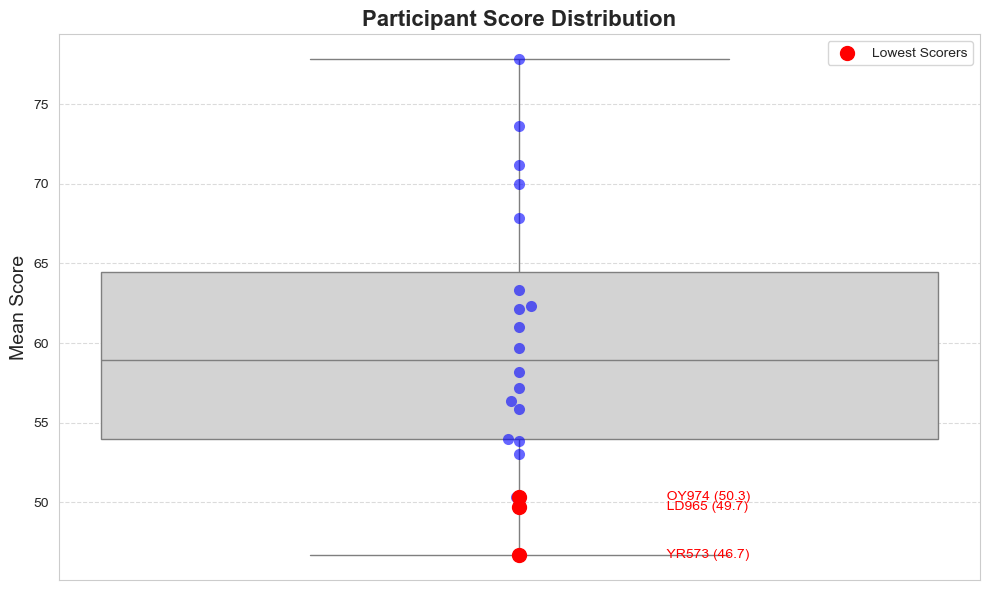

In [88]:
# are the worse (score) really far from the rest? if so not use them
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_score_distribution(df_panels):
    # 1. Aggregate mean score per participant across all their panels
    # Dropping NaNs ensures missing trials don't skew the math
    df_scores = df_panels.groupby('participant')['score'].mean().reset_index()
    df_scores = df_scores.dropna().sort_values(by='score')
    
    # 2. Identify the lowest scorers
    lowest_participants = df_scores.head(3)
    
    # 3. Plotting
    plt.figure(figsize=(10, 6))
    
    # Boxplot shows the statistical distribution (median, quartiles, and outliers)
    sns.boxplot(y=df_scores['score'], color='lightgray', width=0.3, showfliers=False)
    
    # Swarmplot shows every single participant as a dot
    sns.swarmplot(y=df_scores['score'], color='blue', size=8, alpha=0.6)
    
    # Highlight the worst participants in red and label them
    plt.scatter(
        x=[0]*len(lowest_participants), 
        y=lowest_participants['score'], 
        color='red', 
        s=100, 
        zorder=10, 
        label='Lowest Scorers'
    )
    
    for _, row in lowest_participants.iterrows():
        plt.text(
            0.05, row['score'], 
            f"  {row['participant']} ({row['score']:.1f})", 
            color='red', fontsize=10, verticalalignment='center'
        )

    plt.title("Participant Score Distribution", fontsize=16, weight='bold')
    plt.ylabel("Mean Score", fontsize=14)
    plt.xticks([]) # Hide X axis since it's just a 1D distribution
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Execute using the dataframe from the previous step
plot_score_distribution(df_panels)

In [89]:
# what is the minimum number of trials that the top 90% of participants have? (to decide on a cutoff for dropping participants with too few trials)

import pandas as pd

def get_min_trials_top_90(df_trials, df_panels):
    # 1. Count total valid trials per participant (ignoring panels)
    trial_counts = df_trials.groupby('participant').size().reset_index(name='total_trials')
    
    # 2. Extract the participant's mean score
    mean_scores = df_panels.groupby('participant')['score'].mean().reset_index()
    
    # 3. Merge the counts and scores
    df_metrics = pd.merge(trial_counts, mean_scores, on='participant', how='inner')
    
    # 4. Determine the score threshold for the top 90% (drop the bottom 10%)
    score_cutoff = df_metrics['score'].quantile(0.10)
    
    # 5. Isolate the top 90% cohort
    top_90_cohort = df_metrics[df_metrics['score'] >= score_cutoff]
    
    # 6. Find the absolute minimum trial count in this group
    min_trials = top_90_cohort['total_trials'].min()
    
    print(f"--- Top 90% Cohort Analysis ---")
    print(f"Score Cutoff (10th percentile): {score_cutoff:.2f}")
    print(f"Number of Participants in Top 90%: {len(top_90_cohort)} / {len(df_metrics)}")
    print(f"Minimal Total Trials in this cohort: {min_trials}")
    
    return min_trials

# Execute
min_trials_val = get_min_trials_top_90(df_trials, df_panels)

--- Top 90% Cohort Analysis ---
Score Cutoff (10th percentile): 50.00
Number of Participants in Top 90%: 14 / 16
Minimal Total Trials in this cohort: 156


In [ ]:
#CHOSEN VERSION - with scatter plots of the random splits

import os
import numpy as np
import matplotlib.pyplot as plt

def plot_correlation_hist(array, l_size, subject_amount, feature_name, save_path=None):
    plt.figure(figsize=(8, 5))
    plt.hist(array, bins=50, color='skyblue', edgecolor='black', alpha=0.8)
    plt.axvline(np.mean(array), color='red', linestyle='dashed', linewidth=2, label=f'Mean r: {np.mean(array):.3f}')
    plt.title(f"{feature_name} - Reliability Distribution (L={l_size})\nOver {len(array)} repetitions, N={subject_amount}")
    plt.xlabel("Pearson Correlation (r)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(axis='y', alpha=0.5)
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

def plot_random_scatter(half_a, half_b, r_value, feature_name, l_size, iteration, save_path):
    plt.figure(figsize=(6, 6))
    plt.scatter(half_a, half_b, color='teal', alpha=0.7)
    
    # Add a basic trendline
    if len(half_a) > 1:
        z = np.polyfit(half_a, half_b, 1)
        p = np.poly1d(z)
        # Sort for a clean line plot
        sorted_indices = np.argsort(half_a)
        plt.plot(np.array(half_a)[sorted_indices], p(np.array(half_a)[sorted_indices]), "r--", alpha=0.8)

    plt.title(f"{feature_name} - Split-Half Scatter\n(L={l_size}, Iteration={iteration}) r={r_value:.3f}")
    plt.xlabel("Mean Score (Split Half A)")
    plt.ylabel("Mean Score (Split Half B)")
    plt.grid(True, alpha=0.3)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()

def calculate_reliability(data, L_size, repetitions, min_value, feature_name, save_dir=None, plot=True, extract_scatters=False):
    array_corr = np.zeros(repetitions)
    subjects_amount = len(data)
    
    # Select 2 random iterations to plot if requested
    random_iters = np.random.choice(repetitions, 2, replace=False) if extract_scatters else []
    
    for i in range(repetitions):
        shuffle_data = np.random.permutation(np.arange(min_value))
        selected_matrix_1 = []
        selected_matrix_2 = []
        
        for participant_idx in range(subjects_amount):
            matrix_1 = data[participant_idx][shuffle_data[:L_size]]
            matrix_2 = data[participant_idx][shuffle_data[L_size:2*L_size]]
            selected_matrix_1.append(np.mean(matrix_1))
            selected_matrix_2.append(np.mean(matrix_2))

        r_val = np.corrcoef(selected_matrix_1, selected_matrix_2)[0, 1]
        array_corr[i] = r_val
        
        # Save scatter plot if this iteration was randomly selected
        if i in random_iters and save_dir:
            scatter_path = os.path.join(save_dir, f"{feature_name}_scatter_iter_{i}_L{L_size}.png")
            plot_random_scatter(selected_matrix_1, selected_matrix_2, r_val, feature_name, L_size, i, scatter_path)
        
    if plot and save_dir:
        hist_path = os.path.join(save_dir, f"{feature_name}_max_split_hist_L{L_size}.png")
        plot_correlation_hist(array_corr, L_size, subjects_amount, feature_name, hist_path)
        
    return np.mean(array_corr), L_size

def calculate_reliability_distribution(data, min_l, max_l, repetitions, min_value, feature_name):
    results = []
    for l_value in range(max(5, min_l), max_l + 1):
        # We don't save scatters or histograms for the intermediate steps to prevent clutter
        mean_value, _ = calculate_reliability(data, l_value, repetitions, min_value, feature_name, plot=False)
        results.append(mean_value)
    return results


def evaluate_feature_reliability(df_trials, feature_name, min_trials=150, repetitions=1000):
    base_dir = "/Volumes/ramot/Noam_M/preliminary_results/all_features/feature reliability"
    feature_dir = os.path.join(base_dir, feature_name)
    os.makedirs(feature_dir, exist_ok=True)
    
    trial_counts = df_trials.groupby('participant')[feature_name].count()
    valid_participants = trial_counts[trial_counts >= min_trials].index.tolist()
    
    if len(valid_participants) < 3:
        print(f"Not enough participants have {min_trials} valid trials for {feature_name}.")
        return
        
    data_matrix = []
    for p in valid_participants:
        vals = df_trials[df_trials['participant'] == p][feature_name].dropna().values
        data_matrix.append(vals[:min_trials])
        
    data_matrix = np.array(data_matrix)
    print(f"\nProcessing: {feature_name} (N={len(valid_participants)})")
    
    max_l = min_trials // 2
    l_values = list(range(5, max_l + 1))
    
    mean_correlations = calculate_reliability_distribution(
        data_matrix, min_l=5, max_l=max_l, repetitions=repetitions, min_value=min_trials, feature_name=feature_name
    )
    
    # 1. Save Growth Curve
    plt.figure(figsize=(8, 5))
    plt.plot(l_values, mean_correlations, marker='o', linestyle='-', color='purple')
    plt.title(f"{feature_name} - Reliability Growth Curve")
    plt.xlabel("L Size (Number of trials in each split-half)")
    plt.ylabel("Mean Pearson Correlation (r)")
    plt.ylim(-0.1, 1.0)
    plt.grid(True, alpha=0.5)
    
    curve_path = os.path.join(feature_dir, f"{feature_name}_growth_curve.png")
    plt.savefig(curve_path, dpi=150, bbox_inches='tight')
    plt.close() 
    
    # 2. Compute final max split, save its histogram, and extract the 2 random scatters
    calculate_reliability(
        data_matrix, 
        L_size=max_l, 
        repetitions=repetitions, 
        min_value=min_trials,
        feature_name=feature_name,
        save_dir=feature_dir,
        plot=True, 
        extract_scatters=True
    )

# Execution
df_trials = pd.read_csv("/Volumes/ramot/Noam_M/preliminary_results/all_features/features_table_02_05_2026.csv")
df_trials = df_trials[~df_trials['participant'].isin(['PT914', 'LY082', 'KH736'])]
feature_columns = [col for col in df_trials.columns if col not in ['participant', 'panel', 'trial_idx']]
for feature in feature_columns:
    evaluate_feature_reliability(df_trials, feature_name=feature, min_trials=150, repetitions=1000)


Processing: first5_last5_slope (N=64)


In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.colors import LinearSegmentedColormap

# --- PATHS ---
BASE_DIR = "/Volumes/ramot/Noam_M/preliminary_results/all_features/"
CORR_DIR = os.path.join(BASE_DIR, "features correlations")
os.makedirs(CORR_DIR, exist_ok=True)

TRIAL_TABLE_PATH = os.path.join(BASE_DIR, "features_table_26_04_2026.csv")
PANEL_TABLE_PATH = os.path.join(BASE_DIR, "panel_features_table_20_04_2026.csv")
NEW_PANEL_TABLE_PATH = os.path.join(BASE_DIR, "panel_features_table_26_04_2026.csv")
PARTICIPANT_TABLE_PATH = os.path.join(BASE_DIR, "participant_features_table_26_04_2026.csv")

# ==========================================
# TASK 1: Update Panel Table
# ==========================================
print("Updating panel table with num_of_searches_per_trial...")
df_trials = pd.read_csv(TRIAL_TABLE_PATH)
df_panels = pd.read_csv(PANEL_TABLE_PATH)

# Calculate panel-level stats for the missing feature
panel_stats = df_trials.groupby(['participant', 'panel'])['num_of_searches_per_trial'].agg(
    mean='mean', median='median', sd='std'
).reset_index()

panel_stats.rename(columns={
    'mean': 'num_of_searches_per_trial_mean',
    'sd': 'num_of_searches_per_trial_sd'
}, inplace=True)

# Drop columns if they exist to prevent _x/_y suffixes, then merge
update_cols = ['num_of_searches_per_trial_mean', 'num_of_searches_per_trial_sd']
df_panels = df_panels.drop(columns=[col for col in update_cols if col in df_panels.columns])
df_panels = pd.merge(df_panels, panel_stats, on=['participant', 'panel'], how='left')

# Save updated panel table
df_panels.to_csv(NEW_PANEL_TABLE_PATH, index=False)

Updating panel table with num_of_searches_per_trial...


In [37]:
# ==========================================
# TASK 2: Create Participant Level Aggregation
# ==========================================
BASE_DIR = "/Volumes/ramot/Noam_M/preliminary_results/all_features/"

TRIAL_TABLE_PATH = os.path.join(BASE_DIR, "features_table_02_06_2026.csv")
PANEL_TABLE_PATH = os.path.join(BASE_DIR, "panel_features_table_02_06_2026.csv")
PARTICIPANT_TABLE_PATH = os.path.join(BASE_DIR, "participant_features_table_02_06_2026.csv")
df_trials = pd.read_csv(TRIAL_TABLE_PATH)
df_panels = pd.read_csv(PANEL_TABLE_PATH)

print("Aggregating participant-level features...")
feature_cols = [
    "dispersions_global_bcea", "dispersions_global_rms", "fixation_counts_per_trial",
    "symbol_counts_per_trial", "trial_in_search_durations", "time_in_relevant_fixations",
    "num_of_searches_per_trial", "unique_counts_per_trial"
]

# Aggregate over ALL trials (mathematically optimal)
participant_stats = df_trials.groupby('participant')[feature_cols].agg(['mean', 'std'])

# Flatten multi-index columns (e.g., 'fixation_counts_per_trial', 'mean' -> 'fixation_counts_per_trial_mean')
participant_stats.columns = [f"{col[0]}_{col[1]}" for col in participant_stats.columns]
participant_stats = participant_stats.reset_index()

# Get mean score per participant from the panel table to use for color coding
scores = df_panels.groupby('participant')['score'].mean().reset_index()
df_participants = pd.merge(participant_stats, scores, on='participant', how='left')

# Drop rows with entirely missing feature sets if any exist
df_participants = df_participants.dropna(subset=participant_stats.columns[1:], how='all')
df_participants.to_csv(PARTICIPANT_TABLE_PATH, index=False)

Aggregating participant-level features...


In [146]:
import os
import pandas as pd

# --- PATHS ---
BASE_DIR = "/Volumes/ramot/Noam_M/preliminary_results/all_features/"
PARTICIPANT_FILE = os.path.join(BASE_DIR, "participant_features_table_02_05_2026.csv")
TRIAL_FILE = os.path.join(BASE_DIR, "features_table_with_typicality.csv")

print("Loading participant table...")
df_participants = pd.read_csv(PARTICIPANT_FILE)

# 1. Pop old typicality columns (safe drop in case they don't exist)
cols_to_drop = [col for col in ['typicality_std', 'mean_typicality'] if col in df_participants.columns]
if cols_to_drop:
    df_participants = df_participants.drop(columns=cols_to_drop)
    print(f"Dropped old columns: {cols_to_drop}")

print("Loading trial-level data to calculate new typicality stats...")
df_trials = pd.read_csv(TRIAL_FILE)

# 2. Aggregate the new, strict-panel typicality scores per participant
print("Aggregating mean and std typicality per participant...")
typicality_stats = df_trials.groupby('participant')['typicality'].agg(
    mean_typicality='mean',
    typicality_std='std'
).reset_index()

# 3. Merge the new, robust statistics back into the participant table
df_participants = df_participants.merge(typicality_stats, on='participant', how='left')

# 4. Overwrite the participant table
df_participants.to_csv(os.path.join(BASE_DIR, "participant_features_table_02_05_2026_corrected_typicality.csv"), index=False)

print("\nSuccess! Participant table successfully updated with robust 'mean_typicality' and 'typicality_std'.")
print(f"Total participants mapped: {df_participants['mean_typicality'].notna().sum()}")
print(f"Saved to: {PARTICIPANT_FILE}")

Loading participant table...
Dropped old columns: ['typicality_std', 'mean_typicality']
Loading trial-level data to calculate new typicality stats...
Aggregating mean and std typicality per participant...

Success! Participant table successfully updated with robust 'mean_typicality' and 'typicality_std'.
Total participants mapped: 78
Saved to: /Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_02_05_2026.csv


In [144]:
df_participants

,participant,dispersions_global_bcea_mean,dispersions_global_rms_mean,fixation_counts_per_trial_mean,symbol_counts_per_trial_mean,trial_in_search_durations_mean,time_in_relevant_fixations_mean,num_of_searches_per_trial_mean,unique_counts_per_trial_mean,dispersions_global_bcea_std,...,fixation_counts_per_trial_std,symbol_counts_per_trial_std,trial_in_search_durations_std,time_in_relevant_fixations_std,num_of_searches_per_trial_std,unique_counts_per_trial_std,group,score,mean_typicality,typicality_std
0,AG562,847.127254,20.440814,2.099291,1.846336,5.110596e+05,1.431881e+06,0.834515,1.846336,878.376835,...,1.680548,1.491692,4.321047e+05,9.224052e+05,0.425536,1.491692,pwMS,72.500000,-0.992304,1.497394
1,AL371,1150.792497,22.386772,4.500000,3.450000,1.148116e+06,2.272963e+06,1.150000,3.450000,1031.581314,...,2.378313,1.895280,6.358918e+05,1.283166e+06,0.461448,1.895280,pwMS,45.333333,0.362650,1.988454
2,AM367,970.006256,17.808563,18.884120,4.300429,1.334286e+06,2.210099e+06,1.386266,4.300429,881.789743,...,17.044803,3.746820,1.536090e+06,2.011817e+06,0.854088,3.746820,HC,40.833333,1.178176,3.789271
3,AN814,1177.603623,22.904510,4.971831,3.605634,8.859912e+05,1.809335e+06,1.208451,3.605634,966.672025,...,2.682712,2.182874,4.940034e+05,1.126862e+06,0.516875,2.182874,HC,61.166667,0.645817,2.239577
4,AS038,1195.158262,24.012102,5.933673,2.658163,6.901482e+05,1.462261e+06,0.938776,2.658163,1014.609374,...,4.165464,1.743232,4.381497e+05,8.866973e+05,0.406251,1.743232,pwMS,67.333333,-0.231029,1.779814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,YS514,1386.305335,23.520834,7.156627,4.052209,1.146774e+06,2.809823e+06,1.216867,4.052209,1220.666755,...,4.787792,2.782666,7.770983e+05,1.775164e+06,0.501165,2.782666,pwMS,43.500000,0.951462,2.822357
74,ZA720,1403.033114,26.903658,4.322176,1.843096,3.760341e+05,1.675418e+06,0.767782,1.843096,1064.973480,...,4.174492,1.605306,3.273569e+05,8.759702e+05,0.524502,1.605306,pwMS,81.666667,-0.815421,1.537127
75,ZL881,1201.941134,23.995981,5.265861,3.413897,9.260934e+05,1.786920e+06,1.015106,3.413897,998.435118,...,2.520584,1.794179,4.397944e+05,1.047224e+06,0.251808,1.794179,pwMS,57.166667,0.425025,1.894670
76,ZN290,1472.007928,26.152612,11.425220,3.533724,9.363108e+05,2.066133e+06,1.058651,3.533724,1137.880416,...,10.673131,3.513362,9.537544e+05,1.651749e+06,0.475354,3.513362,pwMS,58.833333,0.562304,3.547775


In [60]:
df_participants = pd.read_csv("/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_02_06_2026.csv")
df_panels = pd.read_csv("/Volumes/ramot/Noam_M/preliminary_results/all_features/panel_features_table_02_06_2026_reduced.csv")

In [64]:
df_participants.columns

Index(['participant', 'dispersions_global_bcea_mean',
       'dispersions_global_bcea_std', 'dispersions_global_rms_mean',
       'dispersions_global_rms_std', 'fixation_counts_per_trial_mean',
       'fixation_counts_per_trial_std', 'symbol_counts_per_trial_mean',
       'symbol_counts_per_trial_std', 'trial_in_search_durations_mean',
       'trial_in_search_durations_std', 'time_in_relevant_fixations_mean',
       'time_in_relevant_fixations_std', 'num_of_searches_per_trial_mean',
       'num_of_searches_per_trial_std', 'unique_counts_per_trial_mean',
       'unique_counts_per_trial_std', 'score', 'fixation_bcea_mean',
       'fixation_bcea_std', 'Group', 'Gender', 'Age_Years', 'Months_Sick',
       'KD_Total', 'CCMT_Acc_Combined', 'CFMT_Acc_Combined'],
      dtype='object')

In [74]:
df_participants = pd.read_csv("/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_02_06_2026.csv")
#delete patricipants [['PT914', 'LY082', 'KH736']]
df_participants = df_participants[~df_participants['participant'].isin(['PT914', 'LY082', 'KH736'])]
#do not use markov features for now
features_to_correlate =[
    'dispersions_global_bcea_mean', 'dispersions_global_rms_mean', 'fixation_counts_per_trial_mean',
    'symbol_counts_per_trial_mean','trial_in_search_durations_mean', 'time_in_relevant_fixations_mean',
    'num_of_searches_per_trial_mean', 'unique_counts_per_trial_mean',
    'score', 'fixation_bcea_mean','fixation_bcea_std', 'Group', 'Gender', 'Age_Years', 'Months_Sick',
       'KD_Total', 'CCMT_Acc_Combined', 'CFMT_Acc_Combined']

# Extract only the feature columns that include these names
df_participants = df_participants[features_to_correlate].copy()

# ==========================================
# FIX: Convert Categorical Strings to Numeric
# ==========================================
# Map Group to binary (HC=0, MS/pwMS=1)
if 'Group' in df_participants.columns:
    df_participants['Group'] = df_participants['Group'].map({'HC': 0, 'MS': 1, 'pwMS': 1})

# Map Gender to binary (Adjust string keys if your table uses 'Male'/'Female')
if 'Gender' in df_participants.columns:
    df_participants['Gender'] = df_participants['Gender'].map({'M': 0, 'F': 1, 'Male': 0, 'Female': 1})

# Force every column to be explicitly numeric. Non-numeric artifacts will become NaN.
for col in features_to_correlate:
    df_participants[col] = pd.to_numeric(df_participants[col], errors='coerce')

In [79]:
from scipy.stats import pearsonr
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
#using only reliable features - correlation heatmap

# FOR NOW ALL FEATURES ARE RELIABLE - we can decide later which ones to keep based on the reliability results


BASE_DIR = "/Volumes/ramot/Noam_M/preliminary_results/all_features/"
CORR_DIR = os.path.join(BASE_DIR, "features correlations")
# ==========================================
# TASK 3: Heatmap & Correlation Matrices
# ==========================================
print("Calculating correlations and generating heatmap...")
# df_participants = pd.read_csv("/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_02_06_2026.csv")
#delete patricipants [['PT914', 'LY082', 'KH736']]
# df_participants = df_participants[~df_participants['participant'].isin(['PT914', 'LY082', 'KH736'])]
#do not use markov features for now
# features_to_correlate =[
#     'dispersions_global_bcea_mean', 'dispersions_global_rms_mean', 'fixation_counts_per_trial_mean',
#     'symbol_counts_per_trial_mean','trial_in_search_durations_mean', 'time_in_relevant_fixations_mean',
#     'num_of_searches_per_trial_mean', 'unique_counts_per_trial_mean',
#     'score', 'fixation_bcea_mean','fixation_bcea_std', 'Group', 'Gender', 'Age_Years', 'Months_Sick',
#        'KD_Total', 'CCMT_Acc_Combined', 'CFMT_Acc_Combined']

# Extract only the feature columns that include these names
df_participants = df_participants[features_to_correlate]

n_features = len(features_to_correlate)
corr_matrix = pd.DataFrame(np.zeros((n_features, n_features)), columns=features_to_correlate, index=features_to_correlate)
pval_matrix = pd.DataFrame(np.zeros((n_features, n_features)), columns=features_to_correlate, index=features_to_correlate)
annot_matrix = pd.DataFrame(np.empty((n_features, n_features), dtype=str), columns=features_to_correlate, index=features_to_correlate)

# Calculate Pearson r and exact p-values
for col1 in features_to_correlate:
    for col2 in features_to_correlate:
        # Drop NaNs pair-wise to ensure scipy doesn't crash
        valid_idx = df_participants[[col1, col2]].dropna().index
        if len(valid_idx) > 2:
            r, p = pearsonr(df_participants.loc[valid_idx, col1], df_participants.loc[valid_idx, col2])
            corr_matrix.loc[col1, col2] = r
            pval_matrix.loc[col1, col2] = p
            
            # Formatting significance stars
            stars = ""
            if p < 0.001: stars = "***"
            elif p < 0.01: stars = "**"
            elif p < 0.05: stars = "*"
            
            if col1 == col2:
                annot_matrix.loc[col1, col2] = "1.00"
            else:
                annot_matrix.loc[col1, col2] = f"{r:.2f}{stars}"
        else:
            corr_matrix.loc[col1, col2] = np.nan
            pval_matrix.loc[col1, col2] = np.nan
            annot_matrix.loc[col1, col2] = "NaN"

# Save the raw correlation values table
corr_matrix.to_csv(os.path.join(CORR_DIR, "correlation_values_14_05_2026.csv"))

# Build Custom Colormap: Blue (-1) -> White (0) -> Red (1)
colors = ["blue", "white", "red"]
cmap = LinearSegmentedColormap.from_list("custom_blue_red", colors, N=256)

# Mask the diagonal to make it black
mask = np.eye(n_features, dtype=bool)

plt.figure(figsize=(16, 12))
# Setting the axes facecolor to black makes the masked diagonal show as black
plt.gca().set_facecolor('black')

sns.heatmap(
    corr_matrix, 
    annot=annot_matrix, 
    fmt="", 
    cmap=cmap, 
    vmin=-1, vmax=1, 
    mask=mask, 
    linewidths=0.5, 
    linecolor='gray',
    cbar_kws={'label': 'Pearson Correlation (r)'}
)
plt.title("Feature Correlations (Mean & STD over Trials)\n* p<0.05, ** p<0.01, *** p<0.001", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()

heatmap_path = os.path.join(CORR_DIR, "feature_heatmap_03_06_2026.png")
plt.savefig(heatmap_path, dpi=200, bbox_inches='tight')
plt.close()
print(f"Saved Heatmap: {heatmap_path}")


Calculating correlations and generating heatmap...


/var/folders/hm/x0ywtq191fg1bn25skwntmw80000gn/T/ipykernel_1410/2223160967.py:40: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(df_participants.loc[valid_idx, col1], df_participants.loc[valid_idx, col2])
/var/folders/hm/x0ywtq191fg1bn25skwntmw80000gn/T/ipykernel_1410/2223160967.py:40: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(df_participants.loc[valid_idx, col1], df_participants.loc[valid_idx, col2])


Saved Heatmap: /Volumes/ramot/Noam_M/preliminary_results/all_features/features correlations/feature_heatmap_03_06_2026.png


In [82]:
# extracting scatterplots to significant correlation

# ==========================================
# TASK 4: Significant Scatterplots
# ==========================================
print("Extracting scatterplots for significant correlations...")

# Iterate through upper triangle only to avoid duplicating plots (A vs B is the same as B vs A)
significant_pairs_plotted = 0

for i in range(len(features_to_correlate)):
    for j in range(i + 1, len(features_to_correlate)):
        col1 = features_to_correlate[i]
        col2 = features_to_correlate[j]
        p_val = pval_matrix.loc[col1, col2]
        r_val = corr_matrix.loc[col1, col2]
        
        # Check if significant
        if p_val < 0.05:
            significant_pairs_plotted += 1
            plt.figure(figsize=(8, 6))
            
            # Scatterplot colored by Participant Score
            scatter = plt.scatter(
                df_participants[col1], 
                df_participants[col2], 
                c=df_participants['score'], 
                cmap='viridis', 
                s=60, 
                edgecolors='black', 
                alpha=0.8
            )
            
            # Trendline
            valid_idx = df_participants[[col1, col2]].dropna().index
            if len(valid_idx) > 2:
                z = np.polyfit(df_participants.loc[valid_idx, col1], df_participants.loc[valid_idx, col2], 1)
                p_line = np.poly1d(z)
                x_vals = np.linspace(df_participants[col1].min(), df_participants[col1].max(), 100)
                plt.plot(x_vals, p_line(x_vals), "k--", alpha=0.5)

            # Labels and Colorbar
            cbar = plt.colorbar(scatter)
            cbar.set_label('Mean Participant Score', rotation=270, labelpad=15)
            
            stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*"
            plt.title(f"{col1}\nvs\n{col2}\nr = {r_val:.3f} {stars}", pad=15)
            plt.xlabel(col1)
            plt.ylabel(col2)
            plt.grid(True, alpha=0.3)
            
            # Clean filename logic (some feature names might be long)
            safe_col1 = col1.replace("_per_trial", "")
            safe_col2 = col2.replace("_per_trial", "")
            plot_name = f"scatter_{safe_col1}_vs_{safe_col2}.png"
            
            plt.savefig(os.path.join('/Volumes/ramot/Noam_M/preliminary_results/all_features/features correlations/features_scatterplots_03_06_26', plot_name), dpi=150, bbox_inches='tight')
            plt.close()

print(f"Pipeline complete. Generated {significant_pairs_plotted} significant scatterplots.")

Extracting scatterplots for significant correlations...
Pipeline complete. Generated 58 significant scatterplots.


In [ ]:
df_panels.columns

Index(['participant', 'panel', 'score', 'dispersions_global_bcea_mean',
       'dispersions_global_bcea_sd', 'dispersions_global_rms_mean',
       'dispersions_global_rms_sd', 'fixation_counts_per_trial_mean',
       'fixation_counts_per_trial_sd', 'symbol_counts_per_trial_mean',
       'symbol_counts_per_trial_sd', 'trial_in_search_durations_mean',
       'trial_in_search_durations_sd', 'time_in_relevant_fixations_mean',
       'time_in_relevant_fixations_sd', 'num_of_searches_per_trial_mean',
       'num_of_searches_per_trial_sd', 'unique_counts_per_trial_mean',
       'unique_counts_per_trial_sd', 'percent_0_unique_symbols_in_trial',
       'percent_1_unique_symbols_in_trial',
       'percent_2_unique_symbols_in_trial',
       'percent_3_unique_symbols_in_trial',
       'percent_4_unique_symbols_in_trial',
       'percent_5_unique_symbols_in_trial',
       'percent_6_unique_symbols_in_trial',
       'percent_7_unique_symbols_in_trial',
       'percent_8_unique_symbols_in_trial',
   

# PCA and PARETO

In [76]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial import ConvexHull
from itertools import combinations

# --- PATHS ---
BASE_DIR = "/Volumes/ramot/Noam_M/preliminary_results/all_features/"
OUT_DIR = os.path.join(BASE_DIR, "pca and pareto")
os.makedirs(OUT_DIR, exist_ok=True)
FILE_PATH = os.path.join(BASE_DIR, "participant_features_table_26_04_2026.csv")


In [77]:
def plot_scree_elbow(X_scaled, out_dir):
    """Fits a full PCA to plot the explained variance elbow."""
    pca_full = PCA().fit(X_scaled) # Fit all components
    var = pca_full.explained_variance_ratio_ * 100
    cum_var = np.cumsum(var)
    
    plt.figure(figsize=(8, 5))
    plt.bar(range(1, len(var) + 1), var, alpha=0.6, color='blue', label='Individual Variance')
    plt.plot(range(1, len(var) + 1), cum_var, marker='o', color='red', label='Cumulative Variance')
    
    plt.title("Scree / Elbow Plot of Explained Variance", weight='bold')
    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance (%)")
    plt.ylim(0, 105)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "pca_elbow_plot.png"), dpi=150, bbox_inches='tight')
    plt.close()

In [78]:
def plot_pca_weights(pca, features):
    """Plots and saves the PCA loadings (weights) as 3 separate images."""
    for i in range(3):
        plt.figure(figsize=(10, 6))
        weights = pca.components_[i]
        colors = ['red' if w > 0 else 'blue' for w in weights]
        
        plt.bar(features, weights, color=colors)
        plt.title(f"PC{i+1} Weights ({pca.explained_variance_ratio_[i]*100:.1f}% Var) - Participant Level", fontsize=14, weight='bold')
        plt.axhline(0, color='black', linewidth=1)
        plt.grid(axis='y', alpha=0.3)
        plt.xticks(rotation=90)
        
        plt.tight_layout()
        # Saves as PC1, PC2, and PC3 respectively
        filename = os.path.join(OUT_DIR, f"Participant_Level_pca_weights_PC{i+1}.png")
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        plt.close()

In [9]:
def plot_pca_scatters_true_hull(X_pca, pca, df, out_dir):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    var = pca.explained_variance_ratio_ * 100
    
    pairs = [(0, 1), (0, 2), (1, 2)]
    titles = [f"PC1 vs PC2", f"PC1 vs PC3", f"PC2 vs PC3"]
    scores = df['score']
    
    for i, (x_idx, y_idx) in enumerate(pairs):
        ax = axes[i]
        
        # Scatter
        scatter = ax.scatter(X_pca[:, x_idx], X_pca[:, y_idx], c=scores, cmap='viridis', 
                             alpha=0.8, edgecolors='k', s=50)
        
        ax.set_xlabel(f"PC{x_idx+1} ({var[x_idx]:.1f}%)")
        ax.set_ylabel(f"PC{y_idx+1} ({var[y_idx]:.1f}%)")
        ax.set_title(titles[i])
        ax.grid(True, alpha=0.3)
        
        # Compute true 2D Convex Hull for this specific projection
        pts = X_pca[:, [x_idx, y_idx]]
        hull = ConvexHull(pts)
        
        # Draw the polygon perimeter
        for simplex in hull.simplices:
            ax.plot(pts[simplex, 0], pts[simplex, 1], 'r--', linewidth=2)
            
        # Label ALL nodes that make up this specific hull
        for v_idx in hull.vertices:
            p_name = df.iloc[v_idx]['participant']
            ax.scatter(pts[v_idx, 0], pts[v_idx, 1], c='red', s=100, marker='*', zorder=10)
            ax.annotate(p_name, (pts[v_idx, 0], pts[v_idx, 1]), 
                        xytext=(5, 5), textcoords='offset points', 
                        fontsize=9, color='darkred')

    cbar = plt.colorbar(scatter, ax=axes, orientation='horizontal', fraction=0.05, pad=0.15)
    cbar.set_label('Mean Participant Score')
        
    plt.suptitle("PCA Scatters & True Convex Hulls", fontsize=18, weight='bold', y=1.05)
    plt.savefig(os.path.join(out_dir, "Participant_Level_pca_hulls.png"), dpi=150, bbox_inches='tight')
    plt.close()

In [ ]:
# ==========================================
# EXECUTION
# ==========================================
print("Loading participant table...")
df = pd.read_csv(FILE_PATH)

# 1. Clean Data
exclude_cols = ['participant', 'score']
features = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_cols]

# Drop rows that have absolutely no features, then impute remaining NaNs with column medians
df = df.dropna(subset=features, how='all').reset_index(drop=True)
df[features] = df[features].fillna(df[features].median())

X = df[features].values

# 2. Scale Data
print("Scaling data...")
X_scaled = StandardScaler().fit_transform(X)

# 3. Generate Elbow Plot (Fits full PCA internally)
print("Generating Scree/Elbow plot...")
plot_scree_elbow(X_scaled, OUT_DIR)

# 4. Run strict 3-component PCA for the visual scatters
print("Running 3-Component PCA...")
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
    
# 5. Generate Weights and Hull Plots
print("\nGenerating and saving plots...")
plot_pca_weights(pca, features)
plot_pca_scatters_true_hull(X_pca, pca, df, OUT_DIR)

print(f"\nAnalysis complete. All plots saved to: {OUT_DIR}")

## Partial Correlations

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from itertools import combinations

# --- SETTINGS ---
FILE_PATH = "/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_27_04_2026.csv"
ALPHA = 0.05  # Significance threshold

# 1. Load and Clean Data
df = pd.read_csv(FILE_PATH)
exclude_cols = ['participant', 'score']
features = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_cols]

df_clean = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['score']) 
df_clean[features] = df_clean[features].fillna(df_clean[features].median())

# 2. Find all features significantly correlated with the score
sig_with_score = {}
for feat in features:
    # Skip features with zero variance to prevent pearsonr division-by-zero errors
    if df_clean[feat].std() == 0:
        continue
        
    r, p_val = pearsonr(df_clean[feat], df_clean['score'])
    if p_val < ALPHA:
        sig_with_score[feat] = {'r': r, 'p': p_val}

print(f"Found {len(sig_with_score)} features significantly correlated with score (p < {ALPHA}).\n")

# 3. Find orthogonal couples
valid_couples = []
sig_features = list(sig_with_score.keys())

for feat1, feat2 in combinations(sig_features, 2):
    r_inter, p_inter = pearsonr(df_clean[feat1], df_clean[feat2])
    
    # If p_inter >= ALPHA, the features are NOT significantly correlated with each other
    if p_inter >= ALPHA:
        # Calculate a combined predictive power score (sum of absolute r with score) to rank them
        combined_power = abs(sig_with_score[feat1]['r']) + abs(sig_with_score[feat2]['r'])
        valid_couples.append({
            'feat1': feat1,
            'feat2': feat2,
            'feat1_r': sig_with_score[feat1]['r'],
            'feat2_r': sig_with_score[feat2]['r'],
            'inter_r': r_inter,
            'inter_p': p_inter,
            'combined_power': combined_power
        })

# 4. Sort by highest combined predictive power and display
valid_couples.sort(key=lambda x: x['combined_power'], reverse=True)

print(f"--- VALID ORTHOGONAL PREDICTOR COUPLES ---")
print(f"Criteria: Both predict score (p < {ALPHA}), but are independent of each other (p >= {ALPHA})\n")

if not valid_couples:
    print("No couples met the criteria.")
else:
    for i, couple in enumerate(valid_couples, 1):
        print(f"Couple {i}:")
        print(f"  [1] {couple['feat1']} (r with score = {couple['feat1_r']:.3f}) with p = {sig_with_score[couple['feat1']]['p']:.3f}")
        print(f"  [2] {couple['feat2']} (r with score = {couple['feat2_r']:.3f}) with p = {sig_with_score[couple['feat2']]['p']:.3f}")
        print(f"  --> Inter-correlation: r = {couple['inter_r']:.3f}, p = {couple['inter_p']:.3f}\n")

In [ ]:
import os
import pandas as pd
import statsmodels.api as sm
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- PATHS & SETTINGS ---
BASE_DIR = "/Volumes/ramot/Noam_M/preliminary_results/all_features/"
PART_FILE = os.path.join(BASE_DIR, "participant_features_table_02_06_2026.csv")
OUT_DIR = os.path.join(BASE_DIR, "analysis_plots")
os.makedirs(OUT_DIR, exist_ok=True)

OUTLIERS = ['PT914', 'LY082', 'KH736']

VAR_X = 'mean_typicality'
VAR_Y = 'score'

# Dictionary to map raw code names to poster-ready labels
covariates_dict = {
    'dispersions_global_bcea_mean': 'Global Dispersion (BCEA)',
    'fixation_counts_per_trial_mean': 'Fixation Count',
    'symbol_counts_per_trial_mean': 'Symbol Count',
    'trial_in_search_durations_mean': 'Search Duration',
    'time_in_relevant_fixations_mean': 'Time in Relevant Fixations',
    'num_of_searches_per_trial_mean': 'Number of Searches'
}

print("Loading data for iterative partial correlations...")
df = pd.read_csv(PART_FILE)
df_clean = df[~df['participant'].isin(OUTLIERS)].copy()

# 1. Calculate the Uncontrolled (Baseline) Correlation
# Drop rows where X or Y is missing to get a pure baseline
base_df = df_clean.dropna(subset=[VAR_X, VAR_Y])
base_r, base_p = pearsonr(base_df[VAR_X], base_df[VAR_Y])

results = []

# 2. Loop through each covariate individually
for cov_col, cov_label in covariates_dict.items():
    # Only keep rows that have X, Y, AND the specific covariate
    temp_df = df_clean.dropna(subset=[VAR_X, VAR_Y, cov_col])
    
    if len(temp_df) > 2:
        # Regress X on Covariate
        C_const = sm.add_constant(temp_df[cov_col])
        res_x = sm.OLS(temp_df[VAR_X], C_const).fit().resid
        
        # Regress Y on Covariate
        res_y = sm.OLS(temp_df[VAR_Y], C_const).fit().resid
        
        # Correlate the residuals
        partial_r, partial_p = pearsonr(res_x, res_y)
        
        results.append({
            'Controlled Feature': cov_label,
            'Partial_r': partial_r,
            'p_value': partial_p
        })

df_results = pd.DataFrame(results)

print("\n--- ITERATIVE PARTIAL CORRELATION RESULTS ---")
print(f"Original Correlation: r = {base_r:.3f} (p = {base_p:.3e})")
print(df_results.to_string(index=False))

# ==========================================
# POSTER-READY PLOTTING (Bar Chart)
# ==========================================
# Sort results by the partial r value so the bars look organized
df_results = df_results.sort_values('Partial_r', ascending=True)

plt.figure(figsize=(14, 8))

# Define colors based on whether the correlation got stronger or weaker than baseline
# If partial r is closer to 0 than base r, it weakened (covariate explained the effect). 
colors = ['#313695' if abs(r) >= abs(base_r) else '#74add1' for r in df_results['Partial_r']]

ax = sns.barplot(
    data=df_results, 
    x='Partial_r', 
    y='Controlled Feature', 
    hue='Controlled Feature', # assigned to hue to avoid deprecation warning
    palette=colors,
    legend=False,
    edgecolor='black',
    linewidth=2
)

# Draw the Baseline Reference Line
plt.axvline(base_r, color='#a50026', linestyle='--', linewidth=4, zorder=0)

# Add text to explain the red dashed line
plt.text(base_r + 0.01 if base_r > 0 else base_r - 0.01, -0.5, 
         f"Baseline (Uncontrolled) Correlation\nr = {base_r:.3f}", 
         color='#a50026', fontsize=18, fontweight='bold', va='center')

# Annotate each bar with the specific r and p values
for i, row in enumerate(df_results.itertuples()):
    # Add asterisks for significance
    stars = "***" if row.p_value < 0.001 else "**" if row.p_value < 0.01 else "*" if row.p_value < 0.05 else "ns"
    text = f" r = {row.Partial_r:.2f} ({stars})"
    
    # Place text inside or just outside the bar depending on direction
    align = 'left' if row.Partial_r > 0 else 'right'
    offset = 0.01 if row.Partial_r > 0 else -0.01
    
    plt.text(row.Partial_r + offset, i, text, 
             color='black', fontsize=16, fontweight='bold', va='center', ha=align)

# Formatting
plt.title("Effect of Individual Oculomotor Features on the\nTypicality vs. Clinical Score Correlation", 
          fontsize=26, fontweight='bold', pad=20)
plt.xlabel("Partial Pearson Correlation (r)", fontsize=20, fontweight='bold', labelpad=15)
plt.ylabel("Feature Controlled For", fontsize=20, fontweight='bold', labelpad=15)

plt.xticks(fontsize=16)
plt.yticks(fontsize=18, fontweight='bold')

# Ensure the x-axis has enough space for the text labels
xlim = plt.xlim()
plt.xlim(xlim[0] - 0.1, xlim[1] + 0.1)

plt.tight_layout()

out_path = os.path.join(OUT_DIR, "plot_7_iterative_partial_corr_poster.png")
plt.savefig(out_path, dpi=300)
plt.close()

print(f"\nSaved iterative partial correlation poster plot to: {out_path}")

Loading data for iterative partial correlations...

--- ITERATIVE PARTIAL CORRELATION RESULTS ---
Original Correlation: r = -0.410 (p = 1.960e-04)
        Controlled Feature  Partial_r      p_value
  Global Dispersion (BCEA)  -0.383851 5.219093e-04
            Fixation Count  -0.285784 1.120111e-02
              Symbol Count   0.982770 1.748707e-57
           Search Duration   0.539199 3.518762e-07
Time in Relevant Fixations  -0.118843 3.000510e-01
        Number of Searches  -0.185813 1.033601e-01

Saved iterative partial correlation poster plot to: /Volumes/ramot/Noam_M/preliminary_results/all_features/analysis_plots/plot_7_iterative_partial_corr_poster.png


In [62]:
# Couple 1:
# [1] fixation_counts_per_trial_std (r with score = -0.480) with p = 0.000
# [2] time_in_relevant_fixations_mean (r with score = -0.674) with p = 0.000
# --> Inter-correlation: r = 0.212, p = 0.057

# Couple 2:
# [1] time_in_relevant_fixations_mean (r with score = -0.674) with p = 0.000
# [2] num_of_searches_per_trial_std (r with score = -0.439) with p = 0.000
# --> Inter-correlation: r = 0.143, p = 0.202

# Couple 4:
# [1] trial_in_search_durations_mean (r with score = -0.243) with p = 0.029
# [2] time_in_relevant_fixations_std (r with score = -0.775) with p = 0.000
# --> Inter-correlation: r = 0.198, p = 0.077

# Couple 13:
# [1] trial_in_search_durations_mean (r with score = -0.243) with p = 0.029
# [2] time_in_relevant_fixations_mean (r with score = -0.674) with p = 0.000
# --> Inter-correlation: r = 0.176, p = 0.116

# Couple 14:
# [1] symbol_counts_per_trial_mean (r with score = -0.453) with p = 0.000
# [2] num_of_searches_per_trial_std (r with score = -0.439) with p = 0.000
# --> Inter-correlation: r = -0.031, p = 0.783

# Couple 34:
# [1] trial_in_search_durations_mean (r with score = -0.243) with p = 0.029
# [2] num_of_searches_per_trial_std (r with score = -0.439) with p = 0.000
# --> Inter-correlation: r = -0.038, p = 0.739

In [ ]:
# how many participants are in my analisys?
print(f"\nTotal participants included in analysis: {len(df_clean)}")    

#how many did i originaly had?



Total participants included in analysis: 81
Total participants in original table: 81


In [69]:
import os
import pandas as pd

# --- PATHS ---
BASE_DIR = "/Volumes/ramot/Noam_M/preliminary_results/all_features/"
TABLE_PATHS = [
    # os.path.join(BASE_DIR, "features_table_26_04_2026.csv"),
    # os.path.join(BASE_DIR, "panel_features_table_26_04_2026.csv"),
    os.path.join(BASE_DIR, "participant_features_table_26_04_2026.csv")
]

# --- DICTIONARY --- already uploaded
# participants_dict = {
#     'HC': ['OY974', 'KH736', 'PD922', 'LE750', 'LT157', 'TS512', 'EE050', 'FZ767', 'RO755', 'CN205', 'CS653', 'PG184', 'KT158', 'SA803', 'ZM425', 'VA784', 'RL823', 'YR187', 'DM242', 'YR573', 'VA725', 'SN975', 'SE304', 'LD965', 'SS408', 'KS856', 'KS689', 'KN566', 'LY082', 'PO515', 'BL238', 'BY165', 'AN814', 'HA186', 'KS130', 'PA981', 'PR454', 'AS778', 'BO921', 'GS739', 'YO399', 'SO754', 'PT914', 'GI702', 'AM367', 'DD328', 'LT752'], 
#     'pwMS': ['GM552', 'ZA720', 'BR984', 'NG368', 'BR876', 'CM906', 'KT360', 'TM906', 'FS368', 'CN482', 'BA848', 'SM964', 'BV329', 'KD818', 'BR152', 'ZE374', 'ZS065', 'RV501', 'CR991', 'GO777', 'GT239', 'BY832', 'RD707', 'DN859', 'KM269', 'CA984', 'MK547', 'SR081', 'AS038', 'TS243', 'PA356', 'ED186', 'AG562', 'LM308', 'BA755', 'YS875', 'BN201', 'ZN290', 'NK494', 'ZL881', 'BD783', 'SI585', 'ST149', 'GR333', 'RS101', 'AA562', 'PM104', 'II318', 'KH607', 'OM743', 'FF688', 'DI192', 'KI485', 'KO801', 'ZC673', 'LS388', 'ST888', 'AP344', 'MI829', 'YN187', 'LA627', 'SD938', 'KK035', 'MN432', 'KS977', 'KD735', 'SE378', 'AL371', 'KA956', 'DU974', 'PY847', 'YS514', 'NS960', 'KS580', 'DS948']
# }

# 1. Reverse the dictionary for fast O(1) lookups
participant_to_group = {}
for group, participants in participants_dict.items():
    for p in participants:
        participant_to_group[p] = group

# 2. Update and save all tables
for path in TABLE_PATHS:
    if os.path.exists(path):
        print(f"Updating: {os.path.basename(path)}")
        df = pd.read_csv(path)
        
        # Map the group, handling any unmapped participants
        df['group'] = df['participant'].map(participant_to_group)
        
        # Check for unmapped participants
        unmapped = df[df['group'].isna()]['participant'].unique()
        if len(unmapped) > 0:
            print(f"  WARNING: Could not find group for {len(unmapped)} participants: {unmapped}")
        
        # Overwrite the file with the new column
        df.to_csv(path, index=False)
    else:
        print(f"File not found, skipping: {path}")

print("\nDone. The 'group' column has been added to all existing tables.")

# 1. Reverse the dictionary for fast O(1) lookups
participant_to_group = {}
for group, participants in participants_dict.items():
    for p in participants:
        participant_to_group[p] = group

# 2. Update and save all tables
for path in TABLE_PATHS:
    if os.path.exists(path):
        print(f"Updating: {os.path.basename(path)}")
        df = pd.read_csv(path)
        
        # Map the group, handling any unmapped participants
        df['group'] = df['participant'].map(participant_to_group)
        
        # Check for unmapped participants
        unmapped = df[df['group'].isna()]['participant'].unique()
        if len(unmapped) > 0:
            print(f"  WARNING: Could not find group for {len(unmapped)} participants: {unmapped}")
        
        # Overwrite the file with the new column
        df.to_csv(path, index=False)
    else:
        print(f"File not found, skipping: {path}")

print("\nDone. The 'group' column has been added to all existing tables.")

Updating: participant_features_table_26_04_2026.csv

Done. The 'group' column has been added to all existing tables.
Updating: participant_features_table_26_04_2026.csv

Done. The 'group' column has been added to all existing tables.


# creating slope and typicality (of num symbols per trial) columns

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress, ttest_ind
from statsmodels.stats.multitest import multipletests

# --- PATHS & SETTINGS ---
BASE_DIR = "/Volumes/ramot/Noam_M/preliminary_results/all_features/"
TRIAL_TABLE_PATH = os.path.join(BASE_DIR, "features_table_26_04_2026.csv")
PANEL_TABLE_PATH = os.path.join(BASE_DIR, "panel_features_table_26_04_2026.csv")
PARTICIPANT_TABLE_PATH = os.path.join(BASE_DIR, "participant_features_table_26_04_2026.csv")

OUT_DIR = os.path.join(BASE_DIR, "analysis_plots/")
os.makedirs(OUT_DIR, exist_ok=True)

OUTLIERS = ['PT914', 'LY082', 'KH736']
SYMBOL_COL = 'symbol_counts_per_trial' # Ensure this matches your trial-level column name
TRIAL_IDX_COL = 'trial_idx' # The column tracking the trial number
PANEL_COL = 'panel' # The column indicating panel number

# Features to test for MS vs HC
features_to_test = [
    'dispersions_global_bcea_mean', 'fixation_counts_per_trial_mean',
    'symbol_counts_per_trial_mean', 'trial_in_search_durations_mean',
    'time_in_relevant_fixations_mean', 'num_of_searches_per_trial_mean',
    'dispersions_global_bcea_std', 'fixation_counts_per_trial_std',
    'symbol_counts_per_trial_std', 'trial_in_search_durations_std',
    'time_in_relevant_fixations_std', 'num_of_searches_per_trial_std'
]

# =====================================================================
# TASK 1: Slope of first 5 vs last 5 trials (Panel Level)
# =====================================================================
print("--- TASK 1: Calculating Panel Slopes ---")
df_trials = pd.read_csv(TRIAL_TABLE_PATH)
df_trials = df_trials[~df_trials['participant'].isin(OUTLIERS)].copy()

def calculate_panel_slope(group):
    # Sort by trial index to ensure chronological order
    group = group.sort_values(TRIAL_IDX_COL).dropna(subset=[SYMBOL_COL])
    if len(group) < 10:
        return np.nan # Not enough trials to get first 5 and last 5 reliably
    
    # Get first 5 and last 5
    subset = pd.concat([group.head(5), group.tail(5)])
    
    # Linear regression on these 10 points
    slope, _, _, _, _ = linregress(subset[TRIAL_IDX_COL], subset[SYMBOL_COL])
    return slope

# Group by participant and panel, then apply
slopes = df_trials.groupby(['participant', 'panel']).apply(calculate_panel_slope).reset_index(name='first5_last5_slope')

# Merge into panel table and save
df_panels = pd.read_csv(PANEL_TABLE_PATH)
df_panels = df_panels[~df_panels['participant'].isin(OUTLIERS)].copy()
df_panels = df_panels.merge(slopes, on=['participant', 'panel'], how='left')
df_panels.to_csv(os.path.join(BASE_DIR, "panel_features_table_with_slopes.csv"), index=False)

# Plotting Slope Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df_panels['first5_last5_slope'].dropna(), bins=40, kde=True, color='purple')
plt.axvline(0, color='black', linestyle='--', linewidth=1.5)
plt.title("Distribution of Panel Slopes (First 5 vs. Last 5 Trials)")
plt.xlabel("Regression Slope (Change in Symbols per Trial)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_1_panel_slopes_dist.png"), dpi=300)
plt.close()
print("Saved panel slopes to CSV and generated slope histogram.")


--- TASK 1: Calculating Panel Slopes ---


In [141]:

# =====================================================================
# TASK 2: Typicality (Trial Level)
# =====================================================================
df_trials = pd.read_csv(os.path.join(BASE_DIR, "features_table_with_typicality.csv"))
#pop columns typicality, and trial mean
df_trials = df_trials.drop(columns=['typicality', 'trial_mean'], errors='ignore')

PANEL_COL = 'panel'
print("\n--- TASK 2: Calculating Typicality ---")
total_participants = df_trials['participant'].nunique()
# threshold = 0.8 * total_participants
# print(f"Total Participants: {total_participants}. 80% Threshold: {threshold:.1f} participants per trial.")

# Calculate counts and means per trial per panel
trial_stats = df_trials.groupby([PANEL_COL, TRIAL_IDX_COL])[SYMBOL_COL].agg(
    participants_count='count', 
    trial_mean='mean'
).reset_index()

# # Filter trials meeting the 80% threshold
# valid_trials = trial_stats[trial_stats['participants_count'] >= threshold]

# Merge the valid means back to the trial data
df_trials = df_trials.merge(trial_stats[[TRIAL_IDX_COL, 'trial_mean']], on=TRIAL_IDX_COL, how='left')

# Calculate Typicality: Participant Value - Trial Mean
# (Will be NaN for trials that dropped below the 80% threshold)
df_trials['typicality'] = df_trials[SYMBOL_COL] - df_trials['trial_mean']

df_trials.to_csv(os.path.join(BASE_DIR, "features_table_with_typicality.csv"), index=False)

# Plotting Typicality over time
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_trials, x=TRIAL_IDX_COL, y='typicality', errorbar='sd', color='teal')
plt.axhline(0, color='red', linestyle='--', label='Mean Reference (0)')
plt.title("Participant Typicality over Trials (Shaded = ±1 SD)\n(Only showing trials with >= 80% participant retention)")
plt.xlabel("Trial Index")
plt.ylabel("Typicality (Symbol Count - Trial Mean)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_2_typicality_timeline.png"), dpi=300)
plt.close()
print("Saved typicality to CSV and generated typicality timeline plot.")



--- TASK 2: Calculating Typicality ---
Saved typicality to CSV and generated typicality timeline plot.


In [100]:
# 1. LOAD THE ACTUAL PARTICIPANT TABLE
df_participants = pd.read_csv(os.path.join(BASE_DIR, "participant_features_table_26_04_2026.csv"))

# 2. LOAD THE TRIAL TABLE (to calculate the mean from)
df_trials = pd.read_csv('/Volumes/ramot/Noam_M/preliminary_results/all_features/features_table_with_typicality.csv')

# 3. Calculate mean typicality per participant
mean_typicality = df_trials.groupby('participant')['typicality'].mean().reset_index(name='mean_typicality')

# 4. Merge into the participant table
df_participants = df_participants.merge(mean_typicality, on='participant', how='left')

# 5. Save safely
df_participants.to_csv(os.path.join(BASE_DIR, "participant_features_table_02_05_2026.csv"), index=False)

In [ ]:

# =====================================================================
# TASK 3: Statistical Test MS vs HC (Participant Level)
# =====================================================================

features_to_test = [
    'dispersions_global_bcea_mean', 'fixation_counts_per_trial_mean',
    'symbol_counts_per_trial_mean', 'trial_in_search_durations_mean',
    'time_in_relevant_fixations_mean', 'num_of_searches_per_trial_mean', 'typicality_std', 'score', 
     'dispersions_global_bcea_std', 'fixation_counts_per_trial_std', 'mean_typicality',
    'symbol_counts_per_trial_std',
]

print("\n--- TASK 3: MS vs HC Statistical Testing ---")
df_parts = pd.read_csv('/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_02_05_2026.csv')
df_parts = df_parts[~df_parts['participant'].isin(OUTLIERS)].copy()


df_analysis = df_parts[df_parts['group'].isin(['pwMS', 'HC'])]
print(f"Group sizes: {df_analysis['group'].value_counts().to_dict()}")

results = []
for feat in features_to_test:
    if feat not in df_analysis.columns: continue
    
    ms_vals = df_analysis[df_analysis['group'] == 'pwMS'][feat].dropna()
    hc_vals = df_analysis[df_analysis['group'] == 'HC'][feat].dropna()
    
    if len(ms_vals) < 5 or len(hc_vals) < 5: continue
    
    # Independent Welch's t-test (does not assume equal variances)
    t_stat, p_val = ttest_ind(ms_vals, hc_vals, equal_var=False)
    
    results.append({
        'Feature': feat,
        'MS_Mean': ms_vals.mean(),
        'HC_Mean': hc_vals.mean(),
        't_stat': t_stat,
        'p_raw': p_val
    })

results_df = pd.DataFrame(results)

# Apply FDR (False Discovery Rate) correction to p-values
_, p_adj, _, _ = multipletests(results_df['p_raw'], alpha=0.05, method='fdr_bh')
results_df['p_FDR'] = p_adj

print("\nStatistical Results (Sorted by Significance):")
# 1. Explicitly sort by p_raw ascending (lowest p-value/most significant first)
import math

# 1. Sort results by p_raw ascending (most significant first)
results_df = results_df.sort_values('p_raw', ascending=True).reset_index(drop=True)
sorted_features = results_df['Feature'].tolist()

# 2. Setup chunking (4 plots per image)
plots_per_image = 4
num_features = len(sorted_features)
num_images = math.ceil(num_features / plots_per_image) # Calculates how many 2x2 images we need

print(f"\nGenerating {num_images} images to cover all {num_features} features...")

# 3. Loop to create each image
for img_idx in range(num_images):
    # Determine which features go into this specific image (e.g., 0-3, then 4-7)
    start_idx = img_idx * plots_per_image
    end_idx = min(start_idx + plots_per_image, num_features)
    current_features = sorted_features[start_idx:end_idx]

    # Create the 2x2 grid
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    # Plot the features for this chunk
    for i, feat in enumerate(current_features):
        sns.boxplot(data=df_analysis, x='group', y=feat, ax=axes[i], palette={'pwMS': 'lightcoral', 'HC': 'skyblue'})
        sns.stripplot(data=df_analysis, x='group', y=feat, ax=axes[i], color='black', alpha=0.3, jitter=True)
        
        # Add p-value annotations
        p_val = results_df.loc[results_df['Feature'] == feat, 'p_raw'].values[0]
        p_fdr = results_df.loc[results_df['Feature'] == feat, 'p_FDR'].values[0]
        
        # Add the rank to the title (1-based index)
        rank = start_idx + i + 1
        axes[i].set_title(f"Rank {rank}: {feat}\np_raw={p_val:.3f} | p_FDR={p_fdr:.3f}", fontweight='bold')
        axes[i].set_xlabel("")

    # Clean up: If this is the last image and it has fewer than 4 features, hide the empty subplots
    for j in range(len(current_features), 4):
        fig.delaxes(axes[j])

    # Title and Save
    plt.suptitle(f"Features Ranked {start_idx + 1} to {end_idx}: pwMS vs. Healthy Controls", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    filename = f"plot_3_pwMS_vs_HC_ranks_{start_idx + 1}_to_{end_idx}.png"
    filepath = os.path.join(OUT_DIR, filename)
    plt.savefig(filepath, dpi=300)
    plt.close()
    
    print(f"  -> Saved: {filename}")

print("All plots generated successfully!")

In [118]:
df

,participant,dispersions_global_bcea_mean,dispersions_global_rms_mean,fixation_counts_per_trial_mean,symbol_counts_per_trial_mean,trial_in_search_durations_mean,time_in_relevant_fixations_mean,num_of_searches_per_trial_mean,unique_counts_per_trial_mean,dispersions_global_bcea_std,dispersions_global_rms_std,fixation_counts_per_trial_std,symbol_counts_per_trial_std,trial_in_search_durations_std,time_in_relevant_fixations_std,num_of_searches_per_trial_std,unique_counts_per_trial_std,typicality_std,group,mean_typicality
0,AG562,847.127254,20.440814,2.099291,1.846336,5.110596e+05,1.431881e+06,0.834515,1.846336,878.376835,11.428100,1.680548,1.491692,4.321047e+05,9.224052e+05,0.425536,1.491692,1.380145,pwMS,-1.006800
1,AL371,1150.792497,22.386772,4.500000,3.450000,1.148116e+06,2.272963e+06,1.150000,3.450000,1031.581314,10.662333,2.378313,1.895280,6.358918e+05,1.283166e+06,0.461448,1.895280,1.884970,pwMS,0.349874
2,AM367,970.006256,17.808563,18.884120,4.300429,1.334286e+06,2.210099e+06,1.386266,4.300429,881.789743,12.425961,17.044803,3.746820,1.536090e+06,2.011817e+06,0.854088,3.746820,3.741655,HC,1.166346
3,AN814,1177.603623,22.904510,4.971831,3.605634,8.859912e+05,1.809335e+06,1.208451,3.605634,966.672025,10.261207,2.682712,2.182874,4.940034e+05,1.126862e+06,0.516875,2.182874,2.153725,HC,0.634842
4,AS038,1195.158262,24.012102,5.933673,2.658163,6.901482e+05,1.462261e+06,0.938776,2.658163,1014.609374,10.742987,4.165464,1.743232,4.381497e+05,8.866973e+05,0.406251,1.743232,1.668601,pwMS,-0.249345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,YS514,1386.305335,23.520834,7.156627,4.052209,1.146774e+06,2.809823e+06,1.216867,4.052209,1220.666755,11.561237,4.787792,2.782666,7.770983e+05,1.775164e+06,0.501165,2.782666,2.753203,pwMS,0.938738
74,ZA720,1403.033114,26.903658,4.322176,1.843096,3.760341e+05,1.675418e+06,0.767782,1.843096,1064.973480,10.112070,4.174492,1.605306,3.273569e+05,8.759702e+05,0.524502,1.605306,1.412563,pwMS,-0.833884
75,ZL881,1201.941134,23.995981,5.265861,3.413897,9.260934e+05,1.786920e+06,1.015106,3.413897,998.435118,10.723304,2.520584,1.794179,4.397944e+05,1.047224e+06,0.251808,1.794179,1.786817,pwMS,0.413137
76,ZN290,1472.007928,26.152612,11.425220,3.533724,9.363108e+05,2.066133e+06,1.058651,3.533724,1137.880416,9.964296,10.673131,3.513362,9.537544e+05,1.651749e+06,0.475354,3.513362,3.495830,pwMS,0.550445


In [151]:
import os
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# --- PATHS & SETTINGS ---
BASE_DIR = "/Volumes/ramot/Noam_M/preliminary_results/all_features/"
FILE_PATH = os.path.join(BASE_DIR, "participant_features_table_02_05_2026.csv")
OUT_DIR = os.path.join(BASE_DIR, "analysis_plots/")
os.makedirs(OUT_DIR, exist_ok=True)

OUTLIERS = ['PT914', 'LY082', 'KH736']
PREDICTOR_COL = 'mean_typicality'
TARGET_COL = 'score' # Update this if your clinical score column has a different name

print("Loading data for regression analysis...")
df = pd.read_csv(FILE_PATH)

# Clean outliers and drop rows missing the predictor or target
df_clean = df[~df['participant'].isin(OUTLIERS)].copy()
df_clean = df_clean.dropna(subset=[PREDICTOR_COL, TARGET_COL])

# ==========================================
# OLS REGRESSION
# ==========================================
# Define X (Predictor) and y (Target)
X = df_clean[PREDICTOR_COL]
y = df_clean[TARGET_COL]

# Add a constant to the predictor to calculate the intercept
X_with_const = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X_with_const).fit()

print("\n--- OLS REGRESSION RESULTS ---")
print(model.summary())

# Extract specific values for easy reading
r_squared = model.rsquared
p_value = model.pvalues[PREDICTOR_COL]
print(f"\nKey Takeaways:")
print(f"Variance Explained (R-squared): {r_squared:.4f} ({r_squared*100:.1f}%)")
print(f"P-value for {PREDICTOR_COL}: {p_value:.4e}")

# ==========================================
# PLOTTING
# ==========================================
plt.figure(figsize=(10, 8))

# 1. Plot the individual data points colored by group
# Note: Check your raw data. If your label is 'pwMS' instead of 'MS', update the dictionary key below.
sns.scatterplot(
    data=df_clean, 
    x=PREDICTOR_COL, 
    y=TARGET_COL, 
    hue='group',
    palette={'MS': 'red', 'HC': 'blue', 'pwMS': 'red'}, # Handles both 'MS' and 'pwMS' naming conventions
    s=100, 
    alpha=0.7,
    edgecolor='black'
)

# 2. Overlay the overall OLS regression line (without duplicating the scatter dots)
sns.regplot(
    data=df_clean, 
    x=PREDICTOR_COL, 
    y=TARGET_COL, 
    scatter=False, 
    line_kws={'color': 'black', 'linewidth': 3, 'linestyle': '--'}
)

plt.title(f"Regression: Clinical Score vs. Mean Typicality\n$R^2 = {r_squared:.3f}$, $p = {p_value:.3e}$", 
          fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Mean Typicality", fontsize=14, fontweight='bold')
plt.ylabel(f"Clinical Score ({TARGET_COL})", fontsize=14, fontweight='bold')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Group", title_fontsize=14, fontsize=12, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plot_path = os.path.join(OUT_DIR, "plot_4_regression_typicality_colored.png")
plt.savefig(plot_path, dpi=300)
plt.close()

print(f"\nRegression plot saved to: {plot_path}")

Loading data for regression analysis...

--- OLS REGRESSION RESULTS ---
                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.179
Model:                            OLS   Adj. R-squared:                  0.169
Method:                 Least Squares   F-statistic:                     16.63
Date:                Sun, 03 May 2026   Prob (F-statistic):           0.000111
Time:                        13:02:56   Log-Likelihood:                -283.00
No. Observations:                  78   AIC:                             570.0
Df Residuals:                      76   BIC:                             574.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

In [63]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- 1. Modified Calculation Function ---
def calculate_reliability(data, L_size, repetitions, min_value, feature_name, save_dir=None, plot=True, extract_scatters=False):
    array_corr = np.zeros(repetitions)
    subjects_amount = len(data)
    
    random_iters = np.random.choice(repetitions, 2, replace=False) if extract_scatters else []
    
    for i in range(repetitions):
        shuffle_data = np.random.permutation(np.arange(min_value))
        selected_matrix_1 = []
        selected_matrix_2 = []
        
        for participant_idx in range(subjects_amount):
            matrix_1 = data[participant_idx][shuffle_data[:L_size]]
            matrix_2 = data[participant_idx][shuffle_data[L_size:2*L_size]]
            selected_matrix_1.append(np.mean(matrix_1))
            selected_matrix_2.append(np.mean(matrix_2))

        r_val = np.corrcoef(selected_matrix_1, selected_matrix_2)[0, 1]
        array_corr[i] = r_val
        
        # Omitted the scatter plot saving here for brevity, keep your original function if needed
        
    # Return the full array instead of just the mean so we can boxplot it
    return array_corr, L_size

def calculate_reliability_distribution(data, min_l, max_l, repetitions, min_value, feature_name):
    results = []
    for l_value in range(max(5, min_l), max_l + 1):
        array_corr, _ = calculate_reliability(data, l_value, repetitions, min_value, feature_name, plot=False)
        results.append(np.mean(array_corr))
    return results

def evaluate_feature_reliability(df_trials, feature_name, min_trials=150, repetitions=1000):
    trial_counts = df_trials.groupby('participant')[feature_name].count()
    valid_participants = trial_counts[trial_counts >= min_trials].index.tolist()
    
    if len(valid_participants) < 3:
        return None
        
    data_matrix = []
    for p in valid_participants:
        vals = df_trials[df_trials['participant'] == p][feature_name].dropna().values
        data_matrix.append(vals[:min_trials])
        
    data_matrix = np.array(data_matrix)
    max_l = min_trials // 2
    
    # 1. Compute max split to get the full distribution array
    final_array_corr, _ = calculate_reliability(
        data_matrix, L_size=max_l, repetitions=repetitions, 
        min_value=min_trials, feature_name=feature_name, plot=False
    )
    
    return final_array_corr

# --- 2. New Plotting Function ---
def plot_combined_distributions(distributions_dict, save_path):
    features = list(distributions_dict.keys())
    num_features = len(features)
    
    # Create a grid: 2 rows. Top row spans all columns. Bottom row has individual columns.
    fig = plt.figure(figsize=(4 * num_features, 10))
    gs = gridspec.GridSpec(2, num_features, height_ratios=[1, 1])
    
    # --- Top Row: Combined Boxplots ---
    ax_box = fig.add_subplot(gs[0, :])
    data_arrays = [distributions_dict[f] for f in features]
    
    bp = ax_box.boxplot(data_arrays, patch_artist=True, labels=features)
    for box in bp['boxes']:
        box.set_facecolor('skyblue')
        box.set_alpha(0.8)
    
    ax_box.set_title("Reliability Distributions at Maximum Split-Half (N=1000 repetitions)", fontsize=16, fontweight='bold')
    ax_box.set_ylabel("Pearson Correlation (r)", fontsize=12)
    ax_box.grid(axis='y', linestyle='--', alpha=0.6)
    
    # --- Bottom Row: Individual Histograms ---
    for i, feature in enumerate(features):
        ax_hist = fig.add_subplot(gs[1, i])
        arr = distributions_dict[feature]
        
        ax_hist.hist(arr, bins=50, color='skyblue', edgecolor='black', alpha=0.8)
        mean_r = np.mean(arr)
        ax_hist.axvline(mean_r, color='red', linestyle='dashed', linewidth=2, label=f'Mean r: {mean_r:.3f}')
        
        ax_hist.set_title(feature, fontsize=12)
        ax_hist.set_xlabel("Pearson r")
        if i == 0:
            ax_hist.set_ylabel("Frequency")
        ax_hist.legend(loc='upper left', fontsize=9)
        ax_hist.grid(axis='y', alpha=0.3)
        
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Combined plot saved to: {save_path}")

# --- 3. Execution ---
df_trials = pd.read_csv("/Volumes/ramot/Noam_M/preliminary_results/all_features/panel_features_table_02_06_2026_reduced.csv")
df_trials = df_trials[~df_trials['participant'].isin(['PT914', 'LY082', 'KH736'])]
feature_columns = [col for col in df_trials.columns if col not in ['participant', 'panel', 'trial_idx', 'group', 'dispersions_global_rms', 'unique_counts_per_trial', 'trial_mean']]

# Dictionary to hold the raw correlation arrays for each feature
all_distributions = {}

for feature in feature_columns:
    print(f"Processing distribution for: {feature}")
    dist_array = evaluate_feature_reliability(df_trials, feature_name=feature, min_trials=6, repetitions=1000)
    if dist_array is not None:
        all_distributions[feature] = dist_array

# Generate the final composite image
output_path = "/Volumes/ramot/Noam_M/preliminary_results/all_features/combined_reliability_distributions_03_06_2026.png"
plot_combined_distributions(all_distributions, output_path)

Processing distribution for: score
Processing distribution for: dispersions_global_bcea_mean
Processing distribution for: dispersions_global_bcea_sd
Processing distribution for: dispersions_global_rms_mean
Processing distribution for: dispersions_global_rms_sd
Processing distribution for: fixation_counts_per_trial_mean
Processing distribution for: fixation_counts_per_trial_sd
Processing distribution for: symbol_counts_per_trial_mean
Processing distribution for: symbol_counts_per_trial_sd
Processing distribution for: trial_in_search_durations_mean
Processing distribution for: trial_in_search_durations_sd
Processing distribution for: time_in_relevant_fixations_mean
Processing distribution for: time_in_relevant_fixations_sd
Processing distribution for: num_of_searches_per_trial_mean
Processing distribution for: num_of_searches_per_trial_sd
Processing distribution for: unique_counts_per_trial_mean
Processing distribution for: unique_counts_per_trial_sd
Processing distribution for: percent_

/var/folders/hm/x0ywtq191fg1bn25skwntmw80000gn/T/ipykernel_1410/1022478136.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(data_arrays, patch_artist=True, labels=features)


Combined plot saved to: /Volumes/ramot/Noam_M/preliminary_results/all_features/combined_reliability_distributions_03_06_2026.png


In [38]:
df_trials

,participant,panel,trial_idx,dispersions_global_bcea,dispersions_global_rms,fixation_counts_per_trial,symbol_counts_per_trial,trial_in_search_durations,time_in_relevant_fixations,num_of_searches_per_trial,unique_counts_per_trial
0,OY974,0,3,629.630303,27.145171,5,2,946670.0,1645009.0,1,2
1,OY974,0,4,420.158740,21.498804,8,3,1286678.0,4145028.0,1,3
2,OY974,0,5,810.895611,19.513010,6,3,950006.0,3901693.0,1,3
3,OY974,0,6,385.085116,17.673148,15,5,1821679.0,2218347.0,1,5
4,OY974,0,7,576.879352,24.527631,12,6,1863344.0,3116684.0,1,6
...,...,...,...,...,...,...,...,...,...,...,...
26475,DS948,l3,52,1634.321521,26.926438,22,5,1373283.0,2128260.0,1,5
26476,DS948,l3,53,1963.166198,25.528336,8,2,394961.0,2353252.0,1,2
26477,DS948,l3,54,707.325228,26.827719,25,3,1164957.0,1753274.0,1,3
26478,DS948,l3,55,4344.090996,35.801057,35,6,1606613.0,2613217.0,1,6


In [5]:
#how many participants are in my analisys?
#import df trials before print
import pandas as pd
print(f"\nTotal participants included in analysis: {len(df_trials['participant'].unique())}")
#how many with ms and how many healthy controls? (by number of participants)

print(f"Group sizes:\n{df_trials.groupby('group')['participant'].nunique()}")


Total participants included in analysis: 78
Group sizes:
group
HC      29
pwMS    49
Name: participant, dtype: int64


In [147]:
import os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

print("Calculating correlations and generating poster-ready heatmap...")
df_participants = pd.read_csv("/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_02_05_2026_corrected_typicality.csv")

# Delete outliers
df_participants = df_participants[~df_participants['participant'].isin(['PT914', 'LY082', 'KH736'])]

# 1. Map raw feature names to clean, poster-ready labels
feature_rename_dict = {
    'dispersions_global_bcea_mean': 'Global Dispersion (BCEA)',
    'fixation_counts_per_trial_mean': 'Fixation Count',
    'symbol_counts_per_trial_mean': 'Symbol Count',
    'trial_in_search_durations_mean': 'Search Duration',
    'time_in_relevant_fixations_mean': 'Time in Relevant Fixations',
    'num_of_searches_per_trial_mean': 'Number of Searches',
    'mean_typicality': 'Mean Typicality',
    'score': 'SDMT Score'
}

features_to_correlate = list(feature_rename_dict.keys())
poster_labels = list(feature_rename_dict.values())

# Extract only the feature columns
df_participants = df_participants[features_to_correlate]

n_features = len(features_to_correlate)
# Create dataframes using the clean poster labels
corr_matrix = pd.DataFrame(np.zeros((n_features, n_features)), columns=poster_labels, index=poster_labels)
annot_matrix = pd.DataFrame(np.empty((n_features, n_features), dtype=str), columns=poster_labels, index=poster_labels)

# Calculate Pearson r and exact p-values
for i, col1 in enumerate(features_to_correlate):
    for j, col2 in enumerate(features_to_correlate):
        valid_idx = df_participants[[col1, col2]].dropna().index
        
        label1 = poster_labels[i]
        label2 = poster_labels[j]
        
        if len(valid_idx) > 2:
            r, p = pearsonr(df_participants.loc[valid_idx, col1], df_participants.loc[valid_idx, col2])
            corr_matrix.loc[label1, label2] = r
            
            stars = ""
            if p < 0.001: stars = "***"
            elif p < 0.01: stars = "**"
            elif p < 0.05: stars = "*"
            
            if col1 == col2:
                annot_matrix.loc[label1, label2] = "" # Leave diagonal blank
            else:
                annot_matrix.loc[label1, label2] = f"{r:.2f}\n{stars}" # Put stars on a new line for spacing
        else:
            corr_matrix.loc[label1, label2] = np.nan
            annot_matrix.loc[label1, label2] = ""

# Build Custom Colormap: Blue (-1) -> White (0) -> Red (1)
colors = ["#313695", "white", "#a50026"] # Slightly more muted, professional dark blue/red
cmap = LinearSegmentedColormap.from_list("custom_blue_red", colors, N=256)

# Create a Lower Triangle Mask (Hides upper right and diagonal)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Increase figure size for high-res rendering
plt.figure(figsize=(18, 14))

# Heatmap generation with Poster-sized fonts
ax = sns.heatmap(
    corr_matrix, 
    annot=annot_matrix, 
    fmt="", 
    cmap=cmap, 
    vmin=-1, vmax=1, 
    mask=mask, 
    linewidths=2,         # Thicker lines between cells
    linecolor='white',    # White lines look cleaner on posters
    cbar_kws={'label': 'Pearson Correlation (r)'},
    annot_kws={"size": 18, "weight": "bold"} # Huge, bold text inside cells
)

# Colorbar adjustments
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
cbar.set_label('Pearson Correlation (r)', size=20, weight='bold', labelpad=15)

# Axis and Title formatting
plt.title("Low/Mid Level Feature Correlations", fontsize=32, fontweight='bold', pad=30)
plt.xticks(rotation=45, ha='right', fontsize=22)
plt.yticks(rotation=0, fontsize=22)

# Add a clean subtitle/legend for the p-values
plt.figtext(0.5, -0.05, "$* p < 0.05 \quad ** p < 0.01 \quad *** p < 0.001$", 
            ha="center", fontsize=20, style='italic')

plt.tight_layout()

heatmap_path = os.path.join(CORR_DIR, "feature_heatmap_02_05_2026_corrected typicality.png")
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight', transparent=True)
plt.close()

print(f"Saved Poster Heatmap: {heatmap_path}")

Calculating correlations and generating poster-ready heatmap...
Saved Poster Heatmap: /Volumes/ramot/Noam_M/preliminary_results/all_features/features correlations/feature_heatmap_02_05_2026_corrected typicality.png


In [153]:
import os
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# --- PATHS & SETTINGS ---
BASE_DIR = "/Volumes/ramot/Noam_M/preliminary_results/all_features/"
FILE_PATH = os.path.join(BASE_DIR, "participant_features_table_02_05_2026.csv")
OUT_DIR = os.path.join(BASE_DIR, "analysis_plots/")
os.makedirs(OUT_DIR, exist_ok=True)

OUTLIERS = ['PT914', 'LY082', 'KH736']
PREDICTOR_COL = 'symbol_counts_per_trial_mean'
TARGET_COL = 'score' 

print("Loading data for symbol count scatter plot...")
df = pd.read_csv(FILE_PATH)

# Clean outliers and drop rows missing the predictor, target, or group
df_clean = df[~df['participant'].isin(OUTLIERS)].copy()
df_clean = df_clean.dropna(subset=[PREDICTOR_COL, TARGET_COL, 'group'])

# ==========================================
# OLS REGRESSION (For overall trendline stats)
# ==========================================
X = df_clean[PREDICTOR_COL]
y = df_clean[TARGET_COL]

X_with_const = sm.add_constant(X)
model = sm.OLS(y, X_with_const).fit()

r_squared = model.rsquared
p_value = model.pvalues[PREDICTOR_COL]

print(f"\n--- REGRESSION STATS ---")
print(f"Variance Explained (R-squared): {r_squared:.4f}")
print(f"P-value: {p_value:.4e}")

# ==========================================
# POSTER-READY PLOTTING
# ==========================================
plt.figure(figsize=(10, 8))

# 1. Scatter points colored by group
sns.scatterplot(
    data=df_clean, 
    x=PREDICTOR_COL, 
    y=TARGET_COL, 
    hue='group',
    palette={'MS': '#a50026', 'HC': '#313695', 'pwMS': '#a50026'}, # Handles 'MS' or 'pwMS' naming
    s=120,          # Large dots for visibility
    alpha=0.8,
    edgecolor='black',
    linewidth=1
)

# 2. Overall regression line (dashed black)
sns.regplot(
    data=df_clean, 
    x=PREDICTOR_COL, 
    y=TARGET_COL, 
    scatter=False, 
    line_kws={'color': 'black', 'linewidth': 4, 'linestyle': '--'}
)

plt.title(f"Clinical Score vs. Mean Symbol Count\n$R^2 = {r_squared:.3f}$, $p = {p_value:.3e}$", 
          fontsize=22, fontweight='bold', pad=20)
plt.xlabel("Mean Symbol Count per Trial", fontsize=18, fontweight='bold', labelpad=15)
plt.ylabel(f"Clinical Score ({TARGET_COL})", fontsize=18, fontweight='bold', labelpad=15)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

legend = plt.legend(title="Group", title_fontsize=16, fontsize=14, frameon=True, shadow=True)
legend.get_frame().set_linewidth(2)

plt.grid(True, linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()

plot_path = os.path.join(OUT_DIR, "plot_9_scatter_symbols_vs_score_poster.png")
plt.savefig(plot_path, dpi=300)
plt.close()

print(f"\nPlot successfully saved to: {plot_path}")

Loading data for symbol count scatter plot...

--- REGRESSION STATS ---
Variance Explained (R-squared): 0.2731
P-value: 9.1853e-07

Plot successfully saved to: /Volumes/ramot/Noam_M/preliminary_results/all_features/analysis_plots/plot_9_scatter_symbols_vs_score_poster.png


In [164]:
import pandas as pd

# Load the current participant table
# FILE_PATH = "/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_02_05_2026.csv"
# df = pd.read_csv(FILE_PATH)

# Apply the strict thresholds
condition = (df['score'] < 40) & (df['symbol_counts_per_trial_mean'] >3)
filtered_df = df[condition]

# Extract and display the relevant data
result = filtered_df[['participant', 'group', 'score', 'symbol_counts_per_trial_mean']]

print("Participants with Score < 65 AND Mean Symbol Count < 2:")
print("-" * 65)
if result.empty:
    print("No participants met these criteria.")
else:
    print(result.to_string(index=False))


    # BD783, KI485, PG184, PY847
    # edss: 4.5, 1, 0, 6.5
    #kambridge face accuracy: 40.28, 91.67, 48.61, -

    # cars accuracy: -, 80.56,  65.28, -,  


Participants with Score < 65 AND Mean Symbol Count < 2:
-----------------------------------------------------------------
participant group     score  symbol_counts_per_trial_mean
      DI192  pwMS 37.666667                      4.957944
      GO777  pwMS 37.666667                      3.107477


In [158]:
# is ZC... and LA627 in the table? If so, what are their scores and symbol counts?
specific_participants = ['ZC673', 'LA627']
specific_df = df[df['participant'].isin(specific_participants)][['participant', 'group', 'score', 'symbol_counts_per_trial_mean']]
print("\nSpecific Participants (ZC673 and LA627):")
if specific_df.empty:
    print("Neither ZC673 nor LA627 were found in the table.")


Specific Participants (ZC673 and LA627):
Neither ZC673 nor LA627 were found in the table.


In [165]:
import os
import pandas as pd

# --- PATHS ---
PARTICIPANT_FILE = "/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_02_05_2026.csv"
PANEL_FILE = "/Volumes/ramot/Noam_M/preliminary_results/all_features/panel_features_table_with_slopes.csv"

print("Loading tables...")
df_part = pd.read_csv(PARTICIPANT_FILE)
df_panel = pd.read_csv(PANEL_FILE)

FEATURE_NAME = 'first5_last5_slope'

# 1. Clean up existing columns to prevent _x/_y duplication artifacts
cols_to_drop = [f'{FEATURE_NAME}_mean', f'{FEATURE_NAME}_std']
existing_cols_to_drop = [col for col in cols_to_drop if col in df_part.columns]
if existing_cols_to_drop:
    df_part = df_part.drop(columns=existing_cols_to_drop)
    print(f"Dropped existing old columns to refresh: {existing_cols_to_drop}")

# 2. Aggregate mean and std from the panel table
if FEATURE_NAME in df_panel.columns:
    print(f"Calculating mean and std for '{FEATURE_NAME}' per participant...")
    slope_stats = df_panel.groupby('participant')[FEATURE_NAME].agg(
        first5_last5_slope_mean='mean',
        first5_last5_slope_std='std'
    ).reset_index()

    # 3. Merge into the participant table
    df_part = df_part.merge(slope_stats, on='participant', how='left')

    # 4. Overwrite the updated table
    df_part.to_csv(PARTICIPANT_FILE, index=False)

    print("\nSuccess! Participant table updated with slope statistics.")
    print(f"Total participants successfully mapped: {df_part['first5_last5_slope_mean'].notna().sum()}")
    print(f"Saved to: {PARTICIPANT_FILE}")
else:
    print(f"\nError: Could not find the column '{FEATURE_NAME}' in the panel table.")
    print("Available columns:", df_panel.columns.tolist())

Loading tables...
Calculating mean and std for 'first5_last5_slope' per participant...

Success! Participant table updated with slope statistics.
Total participants successfully mapped: 78
Saved to: /Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_02_05_2026.csv


In [44]:
import numpy as np
import pandas as pd

# Assuming the bcea function we wrote earlier is available in your namespace:
def calculate_bcea(x: np.ndarray, y: np.ndarray, p: float = 0.68) -> float:
    """
    Calculates the Bivariate Contour Ellipse Area (BCEA).
    
    Parameters:
    x (array-like): X coordinates of fixations/microsaccades.
    y (array-like): Y coordinates of fixations/microsaccades.
    p (float): Proportion of data to encompass (default 0.68).
    
    Returns:
    float: The calculated area in squared coordinate units, or NaN if insufficient data.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    
    if len(x) < 3:
        return np.nan

    std_x = np.std(x, ddof=1)
    std_y = np.std(y, ddof=1)
    
    # Handle zero variance edge cases
    if std_x == 0 or std_y == 0:
        return 0.0

    r = np.corrcoef(x, y)[0, 1]
    
    # Calculate the chi-square multiplier for the given probability
    k = -np.log(1 - p)
    
    bcea = 2 * np.pi * k * std_x * std_y * np.sqrt(1 - r**2)
    
    return bcea

def calculate_dispersion_trajectory(fixations: list) -> float:
    """
    Calculates the slope of BCEA dispersion between the first 20 and last 20 fixations.
    Slope = (Mean Last 20 - Mean First 20) / Delta Index
    """
    if len(fixations) < 40:
        return np.nan  # Automatically drop trials with insufficient data

    first_20 = fixations[:20]
    last_20 = fixations[-20:]

    def get_mean_dispersion(fixation_group):
        dispersions = []
        for fix in fixation_group:
            df = fix.microsaccades
            # Covariance matrix requires at least 3 points
            if len(df) > 2: 
                val = calculate_bcea(df['x'].values, df['y'].values)
                if not np.isnan(val) and not np.isinf(val):
                    dispersions.append(val)
        
        if len(dispersions) == 0:
            return np.nan
        return np.mean(dispersions)

    mean_first = get_mean_dispersion(first_20)
    mean_last = get_mean_dispersion(last_20)

    if np.isnan(mean_first) or np.isnan(mean_last):
        return np.nan

    # The "run" (dx) is the distance between the center index of the first bin 
    # and the center index of the last bin.
    # Center of first 20 is index 9.5; Center of last 20 is len(fixations) - 10.5
    delta_x = len(fixations) - 20 
    
    slope = (mean_last - mean_first) / delta_x
    
    return slope



slope_results = []

print("Calculating dispersion slopes for all panels...")

# 2. Iterate through objects and calculate
for participant in participants:
    p_name = participant.name
    
    for panel in participant.trial_managers.keys():
        # Extract the fixations for this specific panel
        fixations = participant.trial_managers[panel].fixations
        
        # Calculate the slope using the function we just wrote
        slope_val = calculate_dispersion_trajectory(fixations)
        
        # Append to our results list
        slope_results.append({
            'participant': p_name,
            'panel': panel,
            'dispersion_first20_last20_slope': slope_val
        })

# 3. Convert the results into a clean DataFrame
df_slopes = pd.DataFrame(slope_results)

# 4. Merge the new slopes into your existing panel DataFrame
# This perfectly aligns the data based on both participant and panel, avoiding any row-index mismatches.
df_panels = df_panels.merge(df_slopes, on=['participant', 'panel'], how='left')

print(f"Successfully calculated and merged slopes for {len(df_slopes)} panel records.")

Calculating dispersion slopes for all panels...
Successfully calculated and merged slopes for 510 panel records.


In [48]:
df_panels.drop(columns = ['percent_3_unique_symbols_in_trial'	,'percent_4_unique_symbols_in_trial', 'percent_5_unique_symbols_in_trial',
              	'percent_6_unique_symbols_in_trial', 'percent_7_unique_symbols_in_trial', 'percent_8_unique_symbols_in_trial', 'percent_9_unique_symbols_in_trial'])


,participant,panel,score,dispersions_global_bcea_mean,dispersions_global_bcea_sd,dispersions_global_rms_mean,dispersions_global_rms_sd,fixation_counts_per_trial_mean,fixation_counts_per_trial_sd,symbol_counts_per_trial_mean,...,time_in_relevant_fixations_sd,num_of_searches_per_trial_mean,num_of_searches_per_trial_sd,unique_counts_per_trial_mean,unique_counts_per_trial_sd,percent_0_unique_symbols_in_trial,percent_1_unique_symbols_in_trial,percent_2_unique_symbols_in_trial,dispersion_first20_last20_slope_x,dispersion_first20_last20_slope_y
0,OY974,0,44.0,1374.724929,966.237059,26.577906,9.193944,6.071429,3.680016,3.500000,...,1.391923e+06,1.142857,0.466569,3.500000,2.061553,2.380952,4.761905,21.428571,0.020243,0.002190
1,OY974,i1,53.0,1587.734350,1197.762062,26.342600,10.481576,6.098039,3.396970,3.529412,...,1.310833e+06,1.039216,0.277297,3.529412,1.446469,1.960784,3.921569,13.725490,0.020243,-0.004538
2,OY974,l4,53.0,1240.021859,915.820815,23.883484,10.740620,4.862745,2.231851,3.137255,...,1.302589e+06,1.039216,0.277297,3.137255,1.521346,1.960784,11.764706,21.568627,0.020243,-0.006891
3,OY974,a3,51.0,1247.743405,963.338967,25.412988,11.071119,5.265306,2.058090,3.306122,...,1.107151e+06,1.061224,0.313516,3.306122,1.459719,2.040816,6.122449,20.408163,0.020243,0.009847
4,OY974,a5,51.0,1308.171863,950.550809,24.365234,10.314978,5.204082,2.320974,3.571429,...,1.115863e+06,1.081633,0.273804,3.571429,1.590790,NaN,6.122449,22.448980,0.020243,0.019015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505,DS948,i1,62.0,1081.859652,1031.942042,20.252735,12.292465,13.166667,11.782992,2.200000,...,1.340706e+06,1.083333,0.736923,2.200000,2.174090,15.000000,31.666667,20.000000,0.020243,-0.009235
506,DS948,l4,70.0,817.305044,977.475123,17.219000,12.737911,6.911765,6.466509,1.764706,...,1.132432e+06,0.852941,0.691646,1.764706,1.535057,26.470588,20.588235,25.000000,0.020243,0.019835
507,DS948,a3,49.0,1378.386003,812.924621,25.362736,8.961499,13.829787,10.937578,4.127660,...,1.399481e+06,1.340426,0.593461,4.127660,2.756941,NaN,NaN,34.042553,0.020243,-0.025382
508,DS948,a5,52.0,1050.493144,869.825676,20.689523,10.580153,14.720000,11.808539,2.000000,...,1.458114e+06,1.220000,0.855336,2.000000,1.637071,18.000000,20.000000,36.000000,0.020243,-0.008947


In [49]:
df_panels.to_csv(os.path.join(BASE_DIR, "panel_features_table_02_06_2026_reduced.csv"), index=False)

In [52]:

PARTICIPANT_FILE = "/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_02_06_2026.csv"
df_participants = pd.read_csv(PARTICIPANT_FILE)

dispersion_results = []

for participant in participants:
    p_name = participant.name
    all_dispersions = []
    
    for panel in participant.trial_managers.keys():
        fixations = participant.trial_managers[panel].fixations
        
        for fix in fixations:
            df = fix.microsaccades
            if len(df) > 2: 
                val = calculate_bcea(df['x'].values, df['y'].values)
                if not np.isnan(val) and not np.isinf(val):
                    all_dispersions.append(val)
    
    if len(all_dispersions) > 0:
        dispersion_results.append({
            'participant': p_name,
            'fixation_bcea_mean': np.mean(all_dispersions),
            'fixation_bcea_std': np.std(all_dispersions, ddof=1)
        })
    else:
        dispersion_results.append({
            'participant': p_name,
            'fixation_bcea_mean': np.nan,
            'fixation_bcea_std': np.nan
        })

# Convert list of dicts to DataFrame
df_new_dispersions = pd.DataFrame(dispersion_results)

# Clean up existing columns to prevent _x/_y duplication artifacts
cols_to_drop = ['fixation_bcea_mean', 'fixation_bcea_std']
existing_cols = [col for col in cols_to_drop if col in df_participants.columns]
if existing_cols:
    df_participants = df_participants.drop(columns=existing_cols)
    print("Dropped old BCEA columns.")

# Merge perfectly aligned by participant
df_participants = df_participants.merge(df_new_dispersions, on='participant', how='left')

# Save updated table
df_participants.to_csv(PARTICIPANT_FILE, index=False)
print("Successfully aggregated and merged overall fixation dispersions to participant table.")


Successfully aggregated and merged overall fixation dispersions to participant table.


In [53]:
import pandas as pd

# --- PATHS ---
PARTICIPANT_FILE = "/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_02_06_2026.csv"
# IMPORTANT: Point this to the newly exported CSV version of Ido's table
IDOS_TABLE_FILE = "/Volumes/ramot/Noam_M/df_filtered_behavioral_summary_20260427_131437.xlsx"

print("Loading tables...")
df_part = pd.read_csv(PARTICIPANT_FILE)
df_ido = pd.read_excel(IDOS_TABLE_FILE)

# ==========================================
# TASK 5: Filter "Tobii_Sucks"
# ==========================================
# Assuming the column contains True/False or 1/0
initial_count = len(df_ido)
df_ido = df_ido[df_ido['Tobii_Sucks'] != True] 
# (If the column is a string like 'Yes'/'No', change to: df_ido['Tobii_Sucks'] != 'Yes')
print(f"Dropped {initial_count - len(df_ido)} participants marked as 'Tobii_Sucks' in Ido's table.")

# ==========================================
# TASK 2 (Part 1): Extract & Merge
# ==========================================
# Select only the columns we actually want to bring over (ignoring 'Trash!' and 'Tobii_Sucks')
cols_to_keep = [
    'Patient_ID', 'Group', 'Gender', 'Age_Years', 
    'Months_Sick', 'KD_Total', 'CCMT_Acc_Combined', 'CFMT_Acc_Combined'
]
df_ido_clean = df_ido[cols_to_keep].copy()

# Rename 'Patient_ID' to 'participant' so the Pandas merge perfectly aligns them
df_ido_clean = df_ido_clean.rename(columns={'Patient_ID': 'participant'})

# Prevent duplicate columns if you run this script twice 
# (e.g., if 'Group' or 'Gender' is already in your main table, we drop it from the main table first to refresh it)
merge_cols = [col for col in cols_to_keep if col != 'Patient_ID']
existing_cols = [col for col in merge_cols if col in df_part.columns]
if existing_cols:
    df_part = df_part.drop(columns=existing_cols)
    print(f"Dropped existing columns in participant table to refresh data: {existing_cols}")

# Execute the Merge (Left merge keeps everyone in your participant table, adding Ido's data where it matches)
df_part = df_part.merge(df_ido_clean, on='participant', how='left')

# Save updated table
df_part.to_csv(PARTICIPANT_FILE, index=False)
print("\nSuccess! Ido's demographic and clinical scores merged into the participant table.")

Loading tables...
Dropped 0 participants marked as 'Tobii_Sucks' in Ido's table.

Success! Ido's demographic and clinical scores merged into the participant table.


In [55]:
df_part.columns

Index(['participant', 'dispersions_global_bcea_mean',
       'dispersions_global_bcea_std', 'dispersions_global_rms_mean',
       'dispersions_global_rms_std', 'fixation_counts_per_trial_mean',
       'fixation_counts_per_trial_std', 'symbol_counts_per_trial_mean',
       'symbol_counts_per_trial_std', 'trial_in_search_durations_mean',
       'trial_in_search_durations_std', 'time_in_relevant_fixations_mean',
       'time_in_relevant_fixations_std', 'num_of_searches_per_trial_mean',
       'num_of_searches_per_trial_std', 'unique_counts_per_trial_mean',
       'unique_counts_per_trial_std', 'score', 'fixation_bcea_mean',
       'fixation_bcea_std', 'Group', 'Gender', 'Age_Years', 'Months_Sick',
       'KD_Total', 'CCMT_Acc_Combined', 'CFMT_Acc_Combined'],
      dtype='object')

In [14]:
import os
import pandas as pd
import numpy as np

# File Paths
TRIAL_PATH = "/Volumes/ramot/Noam_M/preliminary_results/all_features/features_table_02_06_2026.csv"
PANEL_PATH = "/Volumes/ramot/Noam_M/preliminary_results/all_features/panel_features_table_02_06_2026.csv"

trial_accumulator = []
panel_accumulator = []

# Process memory structures
for participant in participants:
    p_name = participant.name
    for panel, trial_manager in participant.trial_managers.items():
        if trial_manager.features:
            if trial_manager.features.revisits_per_trial is not None:
                revisits_dict = trial_manager.features.revisits_per_trial
        else:
            print(f"Warning:  'revisits_per_trial' missing for {p_name} - {panel}")
            continue
            
        # 1. Accumulate Trial-Level Rows
        valid_vals = []
        for t_idx, count in revisits_dict.items():
            trial_accumulator.append({
                "participant": p_name,
                "panel": panel,
                "trial_idx": t_idx,
                "revisits_per_trial": count
            })
            if pd.notnull(count):
                valid_vals.append(count)
        
        # 2. Compute and Accumulate Panel-Level Summary Statistics
        if len(valid_vals) > 0:
            panel_accumulator.append({
                "participant": p_name,
                "panel": panel,
                "revisits_per_trial_mean": np.mean(valid_vals),
                "revisits_per_trial_sd": np.std(valid_vals, ddof=1) if len(valid_vals) > 1 else 0.0
            })
        else:
            panel_accumulator.append({
                "participant": p_name,
                "panel": panel,
                "revisits_per_trial_mean": np.nan,
                "revisits_per_trial_sd": np.nan
            })

# Convert parsed buffers to temporary DataFrames
df_new_trials = pd.DataFrame(trial_accumulator)
df_new_panels = pd.DataFrame(panel_accumulator)

# --- Merge and Overwrite Disk Tables ---
TRIAL_PATH_NEW = "/Volumes/ramot/Noam_M/preliminary_results/all_features/features_table_02_06_2026_w_revisits.csv"
if os.path.exists(TRIAL_PATH):
    df_orig_trials = pd.read_csv(TRIAL_PATH)
    if "_revisits_per_trial" in df_orig_trials.columns:
        df_orig_trials = df_orig_trials.drop(columns=["_revisits_per_trial"])
    df_orig_trials = df_orig_trials.merge(df_new_trials, on=["participant", "panel", "trial_idx"], how="left")
    df_orig_trials.to_csv(TRIAL_PATH_NEW, index=False)
    print(f"Successfully appended '_revisits_per_trial' column to: {TRIAL_PATH}")
PANEL_PATH_NEW = "/Volumes/ramot/Noam_M/preliminary_results/all_features/panel_features_table_02_06_2026_w_revisits.csv"
if os.path.exists(PANEL_PATH):
    df_orig_panels = pd.read_csv(PANEL_PATH)
    for col in ["revisits_per_trial_mean", "revisits_per_trial_sd"]:
        if col in df_orig_panels.columns:
            df_orig_panels = df_orig_panels.drop(columns=[col])
    df_orig_panels = df_orig_panels.merge(df_new_panels, on=["participant", "panel"], how="left")
    df_orig_panels.to_csv(PANEL_PATH_NEW, index=False)
    print(f"Successfully appended panel summary statistics columns to: {PANEL_PATH}")

Successfully appended '_revisits_per_trial' column to: /Volumes/ramot/Noam_M/preliminary_results/all_features/features_table_02_06_2026.csv
Successfully appended panel summary statistics columns to: /Volumes/ramot/Noam_M/preliminary_results/all_features/panel_features_table_02_06_2026.csv


In [15]:
df_orig_panels.head()

,participant,panel,score,dispersions_global_bcea_mean,dispersions_global_bcea_sd,dispersions_global_rms_mean,dispersions_global_rms_sd,fixation_counts_per_trial_mean,fixation_counts_per_trial_sd,symbol_counts_per_trial_mean,...,percent_2_unique_symbols_in_trial,percent_3_unique_symbols_in_trial,percent_4_unique_symbols_in_trial,percent_5_unique_symbols_in_trial,percent_6_unique_symbols_in_trial,percent_7_unique_symbols_in_trial,percent_8_unique_symbols_in_trial,percent_9_unique_symbols_in_trial,revisits_per_trial_mean,revisits_per_trial_sd
0,OY974,0,44.0,1374.724929,966.237059,26.577906,9.193944,6.071429,3.680016,3.500000,...,21.428571,38.095238,9.523810,14.285714,4.761905,NaN,NaN,2.380952,0.0,0.0
1,OY974,i1,53.0,1587.734350,1197.762062,26.342600,10.481576,6.098039,3.396970,3.529412,...,13.725490,35.294118,23.529412,11.764706,7.843137,NaN,1.960784,NaN,0.0,0.0
2,OY974,l4,53.0,1240.021859,915.820815,23.883484,10.740620,4.862745,2.231851,3.137255,...,21.568627,25.490196,25.490196,5.882353,3.921569,3.921569,NaN,NaN,0.0,0.0
3,OY974,a3,51.0,1247.743405,963.338967,25.412988,11.071119,5.265306,2.058090,3.306122,...,20.408163,32.653061,18.367347,14.285714,2.040816,4.081633,NaN,NaN,0.0,0.0
4,OY974,a5,51.0,1308.171863,950.550809,24.365234,10.314978,5.204082,2.320974,3.571429,...,22.448980,24.489796,20.408163,16.326531,4.081633,4.081633,2.040816,NaN,0.0,0.0


In [20]:
# Select the first available participant and panel with data
sample_tm = participants[0].trial_managers[list(participants[0].trial_managers.keys())[0]]
if sample_tm.searches:
    sample_search = sample_tm.searches[0]
    print("Type of cleaned_sequence:", type(sample_search.cleaned_sequence))
    print("Raw contents of cleaned_sequence:", sample_search.cleaned_sequence)
else:
    print("No searches found in sample trial manager.")

Type of cleaned_sequence: <class 'dict'>
Raw contents of cleaned_sequence: {Fixation(start_time=896671.0, end_time=896671.0, position=(np.float64(284.7814178466797), np.float64(109.97823268175125)), duration=0.0 ms): <Symbol 3 (number)>, Fixation(start_time=908339.0, end_time=1101674.0, position=(np.float64(273.28785040439703), np.float64(118.65117891476704)), duration=193335.0 ms): <Symbol 2 (number)>, Fixation(start_time=1145007.0, end_time=1403340.0, position=(np.float64(182.68992020533636), np.float64(61.463340053764675)), duration=258333.0 ms): <Symbol 1 (key)>}


In [24]:
# Select a single participant to audit
test_participant = participants[70] 

print(f"Auditing Value-Based Revisits for Participant: {test_participant.name}")
print("=" * 60)

for panel_id, trial_manager in test_participant.trial_managers.items():
    print(f"\nPanel Layout: {panel_id}")
    
    if hasattr(trial_manager, 'trials') and trial_manager.trials:
        for trial in trial_manager.trials:
            if hasattr(trial, 'searches') and trial.searches:
                flattened_values = []
                
                # Extract values per individual trial search sequence
                for search in trial.searches:
                    if isinstance(search.cleaned_sequence, dict):
                        search_values = [sym.value for sym in search.cleaned_sequence.values()]
                    else:
                        search_values = [sym.value if hasattr(sym, 'value') else sym for sym in search.cleaned_sequence]
                    flattened_values.extend(search_values)
                
                total_count = len(flattened_values)
                unique_count = len(set(flattened_values))
                revisit_count = total_count - unique_count
                
                print(f"  Trial Index {trial.idx:2d} | Sequence: {flattened_values} | Total: {total_count} | Unique: {unique_count} | REVISITS: {revisit_count}")
            else:
                print(f"  Trial Index {trial.idx:2d} | No search sequence populated.")
    else:
        print("  No trials collection found within this trial manager.")

Auditing Value-Based Revisits for Participant: RS101

Panel Layout: 0
  Trial Index  3 | Sequence: [3, 6, 5] | Total: 3 | Unique: 3 | REVISITS: 0
  Trial Index  4 | Sequence: [4, 6, 9] | Total: 3 | Unique: 3 | REVISITS: 0
  Trial Index  5 | Sequence: [5, 8, 3] | Total: 3 | Unique: 3 | REVISITS: 0
  Trial Index  6 | Sequence: [4, 5, 4, 7, 8] | Total: 5 | Unique: 4 | REVISITS: 1
  Trial Index  7 | Sequence: [6, 2, 5, 8, 9] | Total: 5 | Unique: 5 | REVISITS: 0
  Trial Index  8 | Sequence: [7, 3, 4, 5] | Total: 4 | Unique: 4 | REVISITS: 0
  Trial Index  9 | Sequence: [6, 3, 2, 4] | Total: 4 | Unique: 4 | REVISITS: 0
  Trial Index 10 | Sequence: [7, 9, 3, 2] | Total: 4 | Unique: 4 | REVISITS: 0
  Trial Index 11 | Sequence: [3, 6] | Total: 2 | Unique: 2 | REVISITS: 0
  Trial Index 12 | Sequence: [8, 5, 4, 3] | Total: 4 | Unique: 4 | REVISITS: 0
  Trial Index 13 | Sequence: [5, 8] | Total: 2 | Unique: 2 | REVISITS: 0
  Trial Index 14 | Sequence: [4] | Total: 1 | Unique: 1 | REVISITS: 0
  Tria

In [4]:
import glob

# Count total folders to process
total_pwMS = len(glob.glob("/Volumes/ramot/rotation_students/Maysan/Results/data/my_dataset/raw/pwMS/*"))
total_HC = len(glob.glob("/Volumes/ramot/rotation_students/Maysan/Results/data/my_dataset/raw/HC/*"))
total_subjects = total_pwMS + total_HC

# Count how many files your loop has successfully written so far
completed_so_far = len(glob.glob("/Volumes/ramot/Noam_M/preliminary_results/saccade_latency/Maysan_test/raw_100hz/*.csv"))

remaining = total_subjects - completed_so_far
print(f"Total Participants: {total_subjects}")
print(f"Completed: {completed_so_far}")
print(f"Participants Left: {remaining}")

Total Participants: 120
Completed: 92
Participants Left: 28


In [11]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION & PATHS
# ==========================================
csv_path = "/Volumes/ramot/Noam_M/preliminary_results/saccade_latency/Maysan_test/compiled_latencies.csv"
output_plot_path = "/Volumes/ramot/Noam_M/preliminary_results/saccade_latency/Maysan_test/cohort_overlapping_histograms_count.png"

# Load the compiled dataset
df = pd.read_csv(csv_path)

# Full Healthy Control baseline list for grouping
hc_cohort = [
    'AS778', 'CN205', 'CS653', 'GI702', 'KH736', 'KN566', 'KS130', 'KS689', 'KT158', 
    'LD965', 'LE750', 'LG013', 'LT157', 'LY082', 'PR454', 'RL823', 'SA803', 'SE304', 
    'SN975', 'SS408', 'TS512', 'VA725', 'VA784', 'YO399', 'AM367', 'AN814', 'BL238', 
    'GS739', 'KS856', 'PA981', 'PG184', 'PT914', 'RO755', 'SO754', 'ZM425', 'YR187', 
    'DM242', 'YR573', 'PD922', 'PO515', 'BY165', 'LT752'
]

# Map participants to explicit clinical groups
df['Group'] = df['participant'].apply(lambda x: 'HC' if x in hc_cohort else 'pwMS')

# Calculate per-participant metrics while preserving group assignments
df_metrics = df.groupby(['participant', 'Group'])['saccade_latency_ms'].agg(['mean', 'std']).reset_index()

# ==========================================
# PLOTTING (1x3 Clear Layered Histograms)
# ==========================================
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Palette matching your pipeline's theme
palette = {"pwMS": "#f19a9a", "HC": "#9ec8ff"}

# Common keyword arguments for overlapping transparency
hist_kwargs = {
    "hue": "Group",
    "palette": palette,
    "element": "step",       # Outlines the steps so overlapping bars don't get lost
    "stat": "count", 
    "common_norm": False,    # Normalizes each group independently
    "alpha": 0.5,            # Translucent transparency level
    "kde": True              # Smooth density curve overlay
}

# Panel 1: Overlapping Trial Values
sns.histplot(data=df, x="saccade_latency_ms", bins=30, ax=axes[0], **hist_kwargs)
axes[0].set_title("All Trial Values Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Saccade Latency (ms)", fontsize=11)
axes[0].set_ylabel("Density", fontsize=11)

# Panel 2: Overlapping Participant Means
sns.histplot(data=df_metrics, x="mean", bins=20, ax=axes[1], **hist_kwargs)
axes[1].set_title("Participant Means Distribution", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Mean Latency (ms)", fontsize=11)
axes[1].set_ylabel("Density", fontsize=11)

# Panel 3: Overlapping Participant Standard Deviations
sns.histplot(data=df_metrics.dropna(subset=['std']), x="std", bins=20, ax=axes[2], **hist_kwargs)
axes[2].set_title("Participant Standard Deviations (SD)", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Within-Subject SD (ms)", fontsize=11)
axes[2].set_ylabel("Density", fontsize=11)

# Layout presentation clean up
plt.tight_layout()

# Save at a fast, network-friendly resolution (150 DPI) to eliminate I/O hanging
plt.savefig(output_plot_path, dpi=150)
plt.close()

print(f"[SUCCESS] Layered cohort comparison figure generated and saved: {output_plot_path}")

[SUCCESS] Layered cohort comparison figure generated and saved: /Volumes/ramot/Noam_M/preliminary_results/saccade_latency/Maysan_test/cohort_overlapping_histograms_count.png


In [15]:
import pandas as pd

# Load the compiled long-format data
csv_path = "/Volumes/ramot/Noam_M/preliminary_results/saccade_latency/Maysan_test/compiled_latencies.csv"
df = pd.read_csv(csv_path)

# Calculate the mean saccade latency per individual participant (Panel 2 base data)
df_metrics = df.groupby('participant')['saccade_latency_ms'].mean().reset_index(name='mean_latency')

# Compute the mean and standard deviation of this summarized distribution
meta_mean = df_metrics['mean_latency'].mean()
meta_std = df_metrics['mean_latency'].std()
cutoff_threshold = meta_mean + (2 * meta_std)

# Filter for participants whose overall average latency exceeds the threshold
outliers = df_metrics[df_metrics['mean_latency'] > cutoff_threshold]
outliers = outliers.sort_values(by='mean_latency', ascending=False)

# Output summary diagnostics
print(f"Mean of Participant Means: {meta_mean:.4f} ms")
print(f"SD of Participant Means  : {meta_std:.4f} ms")
print(f"Upper 2 SD Cutoff        : {cutoff_threshold:.4f} ms")
print("-" * 50)
print(f"Outlier participants in Panel 2 (Total: {len(outliers)}):\n")
print(outliers.to_string(index=False))

Mean of Participant Means: 0.2161 ms
SD of Participant Means  : 0.0257 ms
Upper 2 SD Cutoff        : 0.2676 ms
--------------------------------------------------
Outlier participants in Panel 2 (Total: 2):

participant  mean_latency
      KA956      0.277260
      SD938      0.276737


In [12]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION & PATHS
# ==========================================
csv_path = "/Volumes/ramot/Noam_M/preliminary_results/saccade_latency/Maysan_test/compiled_latencies.csv"
output_plot_path = "/Volumes/ramot/Noam_M/preliminary_results/saccade_latency/Maysan_test/reliability_r_histogram.png"

# 1. Load data and group into arrays of trial latencies per participant
df = pd.read_csv(csv_path)
participant_groups = df.groupby('participant')['saccade_latency_ms'].apply(list).to_dict()

# Filter out any participants who don't have enough trials to split
valid_participants = {
    pid: np.array(trials, dtype=float) 
    for pid, trials in participant_groups.items() 
    for trials in [df.groupby('participant')['saccade_latency_ms'].get_group(pid).values]
    if len(trials) >= 2
}

print(f"Running reliability permutation on {len(valid_participants)} valid participants...")

# ==========================================
# BOOTSTRAP SPLIT-HALF PERMUTATION
# ==========================================
n_iterations = 10000
r_coefficients = []

for i in range(n_iterations):
    half1_means = []
    half2_means = []
    
    for pid, data in valid_participants.items():
        # Randomly permute the trials for this participant
        shuffled = np.random.permutation(data)
        
        # Split the trials in half
        midpoint = len(shuffled) // 2
        first_half = shuffled[:midpoint]
        second_half = shuffled[midpoint:2 * midpoint]
        
        # Record the mean of each half
        half1_means.append(np.mean(first_half))
        half2_means.append(np.mean(second_half))
        
    # Calculate the Pearson correlation coefficient between the two halves across all subjects
    if len(half1_means) > 1:
        r = np.corrcoef(half1_means, half2_means)[0, 1]
        r_coefficients.append(r)

# ==========================================
# HISTOGRAM GENERATION (COUNT BASED)
# ==========================================
sns.set_style("whitegrid")
plt.figure(figsize=(7, 5))

# Plot raw counts as requested previously
sns.histplot(
    x=r_coefficients,
    stat="count",
    kde=True,
    color="#4c72b0",
    edgecolor="white",
    bins=40
)

mean_r = np.mean(r_coefficients)
plt.axvline(mean_r, color="red", linestyle="--", linewidth=1.5, label=f"Mean $r$ = {mean_r:.4f}")

plt.title("Saccade Latency Split-Half Reliability Distribution", fontsize=12, fontweight="bold")
plt.xlabel("Correlation Coefficient ($r$)", fontsize=11)
plt.ylabel("Permutation Count", fontsize=11)
plt.legend(loc="upper left")

plt.tight_layout()
# Low DPI (150) to prevent network lag during serialization
plt.savefig(output_plot_path, dpi=150)
plt.close()

print(f"[SUCCESS] Calculated {len(r_coefficients)} permutations. Mean reliability r = {mean_r:.4f}")
print(f"Histogram graphic successfully saved to: {output_plot_path}")

Running reliability permutation on 92 valid participants...
[SUCCESS] Calculated 10000 permutations. Mean reliability r = 0.8911
Histogram graphic successfully saved to: /Volumes/ramot/Noam_M/preliminary_results/saccade_latency/Maysan_test/reliability_r_histogram.png


In [19]:
import os
import pandas as pd
import numpy as np
from scipy import stats

# ==========================================
# CONFIGURATION & DATA INGESTION
# ==========================================
behavior_path = "/Volumes/ramot/Noam_M/preliminary_results/behavior_scores/all_scores.csv"
latency_path = "/Volumes/ramot/Noam_M/preliminary_results/saccade_latency/Maysan_test/compiled_latencies.csv"

# Target column definition for behavioral scores (adjust name if different in file)
BEH_SCORE_COL = "SDMT_Score" 

df_beh_raw = pd.read_csv(behavior_path)
df_lat_raw = pd.read_csv(latency_path)

# Calculate participant-level mean metrics
df_beh = df_beh_raw.groupby('Participant')[BEH_SCORE_COL].mean().reset_index(name='SDMT_Score')
df_lat = df_lat_raw.groupby('participant')['saccade_latency_ms'].mean().reset_index(name='mean_latency_ms')

# Merge tables using explicit left and right relational keys to handle case mismatch
df_merged = pd.merge(df_lat, df_beh, left_on='participant', right_on='Participant', how='inner')
print(f"Dataset successfully merged. Total unique participants for analysis: {len(df_merged)}\n")

# ==========================================
# ANALYSIS 1: MEDIAN SPLIT (50% / 50%)
# ==========================================
median_val = df_merged['SDMT_Score'].median()
g_low_med = df_merged[df_merged['SDMT_Score'] <= median_val]['mean_latency_ms']
g_high_med = df_merged[df_merged['SDMT_Score'] > median_val]['mean_latency_ms']

t_med, p_med = stats.ttest_ind(g_low_med, g_high_med, equal_var=False)
print(f"--- Median Split Analysis (Cutoff: {median_val:.2f}) ---")
print(f"Bottom 50% Mean Latency: {g_low_med.mean():.4f} ms (N={len(g_low_med)})")
print(f"Top 50% Mean Latency:    {g_high_med.mean():.4f} ms (N={len(g_high_med)})")
print(f"Welch's t-test: t = {t_med:.4f}, p = {p_med:.4f}\n")

# ==========================================
# ANALYSIS 2: TERTIARY SPLIT (Low, Mid, High)
# ==========================================
q33 = df_merged['SDMT_Score'].quantile(0.333)
q66 = df_merged['SDMT_Score'].quantile(0.666)

g_low_tert = df_merged[df_merged['SDMT_Score'] <= q33]['mean_latency_ms']
g_mid_tert = df_merged[(df_merged['SDMT_Score'] > q33) & (df_merged['SDMT_Score'] <= q66)]['mean_latency_ms']
g_high_tert = df_merged[df_merged['SDMT_Score'] > q66]['mean_latency_ms']

f_stat, p_anova = stats.f_oneway(g_low_tert, g_mid_tert, g_high_tert)
print(f"--- Tertiary Group Split (Low <= {q33:.2f} | Mid | High > {q66:.2f}) ---")
print(f"Low Group Mean Latency:  {g_low_tert.mean():.4f} ms (N={len(g_low_tert)})")
print(f"Mid Group Mean Latency:  {g_mid_tert.mean():.4f} ms (N={len(g_mid_tert)})")
print(f"High Group Mean Latency: {g_high_tert.mean():.4f} ms (N={len(g_high_tert)})")
print(f"One-Way ANOVA: F = {f_stat:.4f}, p = {p_anova:.4f}\n")

# ==========================================
# ANALYSIS 3: FIXED CLINICAL THRESHOLD (60)
# ==========================================
g_below_60 = df_merged[df_merged['SDMT_Score'] < 60]['mean_latency_ms']
g_above_60 = df_merged[df_merged['SDMT_Score'] >= 60]['mean_latency_ms']

print(f"--- Fixed Threshold Analysis (Boundary: 60) ---")
if len(g_below_60) >= 2 and len(g_above_60) >= 2:
    t_thresh, p_thresh = stats.ttest_ind(g_below_60, g_above_60, equal_var=False)
    print(f"Score < 60 Mean Latency:  {g_below_60.mean():.4f} ms (N={len(g_below_60)})")
    print(f"Score >= 60 Mean Latency: {g_above_60.mean():.4f} ms (N={len(g_above_60)})")
    print(f"Welch's t-test: t = {t_thresh:.4f}, p = {p_thresh:.4f}\n")
else:
    print("Skipping threshold t-test: Insufficient sample size in one or both stratified groups.\n")

# ==========================================
# ANALYSIS 4: CONTINUOUS CORRELATION & REGRESSION
# ==========================================
x = df_merged['SDMT_Score']
y = df_merged['mean_latency_ms']

r_val, p_corr = stats.pearsonr(x, y)
slope, intercept, r_sq_val, p_reg, std_err = stats.linregress(x, y)

print(f"--- Continuous Parametric Modeling ---")
print(f"Pearson Correlation: r = {r_val:.4f}, p = {p_corr:.4f}")
print(f"Linear Regression:   y = {slope:.4f}x + {intercept:.4f}")
print(f"Coefficient of Determination: R² = {r_sq_val**2:.4f}")
print(f"Regression Slope Fit Signficance: p = {p_reg:.4f}")

Dataset successfully merged. Total unique participants for analysis: 92

--- Median Split Analysis (Cutoff: 60.67) ---
Bottom 50% Mean Latency: 0.2180 ms (N=46)
Top 50% Mean Latency:    0.2134 ms (N=45)
Welch's t-test: t = 0.8615, p = 0.3915

--- Tertiary Group Split (Low <= 57.17 | Mid | High > 65.93) ---
Low Group Mean Latency:  0.2206 ms (N=31)
Mid Group Mean Latency:  0.2172 ms (N=29)
High Group Mean Latency: 0.2094 ms (N=31)
One-Way ANOVA: F = 1.5656, p = 0.2147

--- Fixed Threshold Analysis (Boundary: 60) ---
Score < 60 Mean Latency:  0.2189 ms (N=40)
Score >= 60 Mean Latency: 0.2132 ms (N=51)
Welch's t-test: t = 1.0483, p = 0.2978

--- Continuous Parametric Modeling ---
Pearson Correlation: r = nan, p = nan
Linear Regression:   y = nanx + nan
Coefficient of Determination: R² = nan
Regression Slope Fit Signficance: p = nan


In [26]:
import os
import pandas as pd

# ==========================================
# CONFIGURATION & DATA INGESTION
# ==========================================
behavior_path = "/Volumes/ramot/Noam_M/preliminary_results/behavior_scores/all_scores.csv"
latency_path = "/Volumes/ramot/Noam_M/preliminary_results/saccade_latency/Maysan_test/compiled_latencies.csv"
output_table_path = "/Volumes/ramot/Noam_M/preliminary_results/saccade_latency/Maysan_test/participant_means_merged.csv"

df_beh_raw = pd.read_csv(behavior_path)
df_lat_raw = pd.read_csv(latency_path)

# Aggregate metrics to the participant level using the updated SDMT column name
df_beh = df_beh_raw.groupby('Participant')['SDMT_Score'].mean().reset_index(name='mean_behavior_score')
df_lat = df_lat_raw.groupby('participant')['saccade_latency_ms'].mean().reset_index(name='mean_latency_ms')

# Resolve key case mismatch and merge datasets
df_merged = pd.merge(df_lat, df_beh, left_on='participant', right_on='Participant', how='inner')

# Clean and isolate relevant columns, discarding records with missing variables
df_output = df_merged[['participant', 'mean_behavior_score', 'mean_latency_ms']].dropna()

# ==========================================
# EXPORT PROCESS
# ==========================================
os.makedirs(os.path.dirname(output_table_path), exist_ok=True)
df_output.to_csv(output_table_path, index=False)

print(f"[SUCCESS] Merged participant-level summary table saved to: {output_table_path}")
print(f"Total structured rows exported: {len(df_output)}")

[SUCCESS] Merged participant-level summary table saved to: /Volumes/ramot/Noam_M/preliminary_results/saccade_latency/Maysan_test/participant_means_merged.csv
Total structured rows exported: 91


In [30]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# ==========================================
# CONFIGURATION & DATA INGESTION
# ==========================================
behavior_path = "/Volumes/ramot/Noam_M/preliminary_results/behavior_scores/all_scores.csv"
latency_path = "/Volumes/ramot/Noam_M/preliminary_results/saccade_latency/Maysan_test/compiled_latencies.csv"
output_table_path = "/Volumes/ramot/Noam_M/preliminary_results/saccade_latency/Maysan_test/participant_means_merged.csv"
output_plot_path = "/Volumes/ramot/Noam_M/preliminary_results/saccade_latency/Maysan_test/latency_vs_sdmt_regression_colored.png"

df_beh_raw = pd.read_csv(behavior_path)
df_lat_raw = pd.read_csv(latency_path)

# 1. Aggregate scores and extract the group assignment column directly from the file
df_beh = df_beh_raw.groupby('Participant').agg(
    mean_behavior_score=('SDMT_Score', 'mean'),
    Group=('Group', 'first')
).reset_index()

# 2. Aggregate latency metrics to the participant level
df_lat = df_lat_raw.groupby('participant')['saccade_latency_ms'].mean().reset_index(name='mean_latency_ms')

# 3. Merge datasets across case-mismatched relational keys
df_merged = pd.merge(df_lat, df_beh, left_on='participant', right_on='Participant', how='inner')

# Isolate columns and drop rows with incomplete variables
df_output = df_merged[['participant', 'mean_behavior_score', 'mean_latency_ms', 'Group']].dropna()

# ==========================================
# EXPORT ENRICHED SUMMARY TABLE
# ==========================================
os.makedirs(os.path.dirname(output_table_path), exist_ok=True)
df_output.to_csv(output_table_path, index=False)
print(f"[SUCCESS] Merged summary table with group labels saved to: {output_table_path}")

# ==========================================
# MODELING & PLOTTING DIRECTLY FROM TABLE
# ==========================================
# Reload directly from disk to ensure storage formatting integrity
df_plot = pd.read_csv(output_table_path)

x = df_plot['mean_behavior_score']
y = df_plot['mean_latency_ms']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(7, 6))

# Map available unique strings in the Group column to a consistent palette
unique_groups = df_plot['Group'].unique()
color_map = {"pwMS": "#f19a9a", "MS": "#f19a9a", "HC": "#9ec8ff", "Control": "#9ec8ff"}
palette = {g: color_map.get(g, "#4c72b0") for g in unique_groups}

# 1. Plot the global linear regression trend line and 95% CI
sns.regplot(
    x=x,
    y=y,
    data=df_plot,
    scatter=False,
    line_kws={'color': '#4a4a4a', 'lw': 2, 'linestyle': '--'},
    ax=ax
)

# 2. Overlay group-stratified scatter points using the table's group column
sns.scatterplot(
    x='mean_behavior_score',
    y='mean_latency_ms',
    hue='Group',
    data=df_plot,
    palette=palette,
    s=55,
    alpha=0.9,
    edgecolor='black',
    linewidths=0.6,
    ax=ax
)

# Statistical metrics annotation box
stats_annotation = f"Pearson $r$ = {r_value:.3f}\n$p$-value = {p_value:.4f}\n$R^2$ = {r_squared:.3f}\n$N$ = {len(df_plot)}"
ax.text(
    0.95, 0.05, stats_annotation,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='bottom',
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.9, edgecolor='0.8')
)

ax.set_title("Oculomotor Latency vs. Cognitive Processing Speed (SDMT)", fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel("Mean SDMT Score", fontsize=11)
ax.set_ylabel("Mean Saccade Latency (ms)", fontsize=11)
ax.legend(title="Cohort Group", loc="upper right", frameon=True)

plt.tight_layout()
plt.savefig(output_plot_path, dpi=150)
plt.close()

print(f"[SUCCESS] Regression figure successfully exported to: {output_plot_path}")

[SUCCESS] Merged summary table with group labels saved to: /Volumes/ramot/Noam_M/preliminary_results/saccade_latency/Maysan_test/participant_means_merged.csv
[SUCCESS] Regression figure successfully exported to: /Volumes/ramot/Noam_M/preliminary_results/saccade_latency/Maysan_test/latency_vs_sdmt_regression_colored.png


In [49]:
# calculating BCEA for all fixations seperatly
import os
import glob
import re
import numpy as np
import pandas as pd
from scipy import stats

# ==========================================
# CONFIGURATION & COLUMN MAPPING
# ==========================================
base_dir = "/Volumes/ramot/Noam_M/Results/Behavior/processing_results"

# Mapping to your exact column schema
X_COL = "eye_horizontal"
Y_COL = "eye_vertical"
TIME_COL = "t"
STATUS_COL = "status"
EVT_COL = "evt"

BCEA_PROBABILITY = 0.6826   # Standard 68.3% spatial containment area
K_CONSTANT = -np.log(1 - BCEA_PROBABILITY)

def calculate_bcea_metrics(group, k_val):
    """Calculates bivariate contour ellipse area and shape diagnostics from normalized coordinates."""
    x_data = pd.to_numeric(group[X_COL], errors='coerce').dropna().values
    y_data = pd.to_numeric(group[Y_COL], errors='coerce').dropna().values
    t_data = pd.to_numeric(group[TIME_COL], errors='coerce').dropna().values
    
    n_points = len(x_data)
    
    # Exclude unstable, transient fixations with insufficient degrees of freedom
    if n_points < 5:
        return pd.Series({
            'bcea': np.nan, 'duration': np.nan, 'n_points': n_points,
            'mean_x': np.nan, 'mean_y': np.nan, 'std_x': np.nan, 'std_y': np.nan
        })
        
    duration = np.max(t_data) - np.min(t_data)
    mean_x, mean_y = np.mean(x_data), np.mean(y_data)
    std_x, std_y = np.std(x_data, ddof=1), np.std(y_data, ddof=1)
    
    if std_x == 0 or std_y == 0:
        return pd.Series({
            'bcea': 0.0, 'duration': duration, 'n_points': n_points,
            'mean_x': mean_x, 'mean_y': mean_y, 'std_x': std_x, 'std_y': std_y
        })
        
    # Pearson product-moment correlation tracking coordinate covariance
    rho, _ = stats.pearsonr(x_data, y_data)
    if np.isnan(rho):
        rho = 0.0
        
    bcea = 2 * k_val * np.pi * std_x * std_y * np.sqrt(1 - rho**2)
    
    return pd.Series({
        'bcea': bcea,
        'duration': duration,
        'n_points': n_points,
        'mean_x': mean_x,
        'mean_y': mean_y,
        'std_x': std_x,
        'std_y': std_y
    })

# ==========================================
# FILE SEARCH AND RUNTIME LOOP
# ==========================================
search_path = os.path.join(base_dir, "*", "task_*_fixation.csv")
all_files = glob.glob(search_path)

participant_files = {}
for filepath in all_files:
    path_parts = filepath.split(os.sep)
    pid = path_parts[-2]  # Extracts folder name as Participant ID
    if pid not in participant_files:
        participant_files[pid] = []
    participant_files[pid].append(filepath)

print(f"Found files for {len(participant_files)} unique participants.")

for pid, file_list in participant_files.items():
    compiled_fixations = []
    
    for filepath in file_list:
        filename = os.path.basename(filepath)
        panel_match = re.search(r'task_(.*?)_fixation\.csv', filename)
        panel_name = panel_match.group(1) if panel_match else "unknown"
        
        try:
            df_raw = pd.read_csv(filepath)
            
            # Verify columns exist
            required_cols = [X_COL, Y_COL, TIME_COL, STATUS_COL, EVT_COL]
            if not all(col in df_raw.columns for col in required_cols):
                print(f"[WARNING] Missing columns in {filepath}. Skipping.")
                continue
            
            # Create unique ID blocks for consecutive rows where evt == 1 and status == 1
            # Every time a break occurs (saccade or invalid data), this counter increments
            is_valid_fixation = (df_raw[EVT_COL] == 1) & (df_raw[STATUS_COL] == 1)
            df_raw['fix_block_id'] = (~is_valid_fixation).cumsum()
            
            # Isolate rows that are part of a valid fixation event
            df_valid_only = df_raw[is_valid_fixation].copy()
            
            if df_valid_only.empty:
                continue
                
            # Process metrics for each independent fixation island
            df_fix = df_valid_only.groupby('fix_block_id').apply(
                lambda g: calculate_bcea_metrics(g, K_CONSTANT), include_groups=False
            ).reset_index(drop=True)
            
            # Append contextual information and a localized sequential counter
            df_fix['panel'] = panel_name
            df_fix['fixation_idx'] = df_fix.index + 1  # 1-indexed count of fixations in this file
            
            compiled_fixations.append(df_fix)
            
        except Exception as e:
            print(f"[ERROR] Failed to process {filepath}: {str(e)}")
            
    if compiled_fixations:
        df_participant_summary = pd.concat(compiled_fixations, ignore_index=True)
        
        # Structure final columns cleanly
        ordered_cols = [
            'panel', 'fixation_idx', 'bcea', 'duration', 
            'n_points', 'mean_x', 'mean_y', 'std_x', 'std_y'
        ]
        df_participant_summary = df_participant_summary[ordered_cols]
        
        # Filter out rows that failed the minimal sampling check (under 5 points)
        df_participant_summary = df_participant_summary.dropna(subset=['bcea'])
        
        # Save table back into the specific participant folder
        output_csv_path = os.path.join(base_dir, pid, "fixation_stability_bcea.csv")
        df_participant_summary.to_csv(output_csv_path, index=False)
        print(f"[SUCCESS] Exported summary for {pid} -> {output_csv_path}")

Found files for 95 unique participants.
[SUCCESS] Exported summary for OY974 -> /Volumes/ramot/Noam_M/Results/Behavior/processing_results/OY974/fixation_stability_bcea.csv
[SUCCESS] Exported summary for KH736 -> /Volumes/ramot/Noam_M/Results/Behavior/processing_results/KH736/fixation_stability_bcea.csv
[SUCCESS] Exported summary for PD922 -> /Volumes/ramot/Noam_M/Results/Behavior/processing_results/PD922/fixation_stability_bcea.csv
[SUCCESS] Exported summary for LE750 -> /Volumes/ramot/Noam_M/Results/Behavior/processing_results/LE750/fixation_stability_bcea.csv
[SUCCESS] Exported summary for GM552 -> /Volumes/ramot/Noam_M/Results/Behavior/processing_results/GM552/fixation_stability_bcea.csv
[SUCCESS] Exported summary for LT157 -> /Volumes/ramot/Noam_M/Results/Behavior/processing_results/LT157/fixation_stability_bcea.csv
[SUCCESS] Exported summary for TS512 -> /Volumes/ramot/Noam_M/Results/Behavior/processing_results/TS512/fixation_stability_bcea.csv
[SUCCESS] Exported summary for ZA720

In [51]:
import os
import glob
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# ==========================================
# CONFIGURATION & DATA INGESTION
# ==========================================
base_dir = "/Volumes/ramot/Noam_M/Results/Behavior/processing_results"
search_path = os.path.join(base_dir, "*", "fixation_stability_bcea.csv")
summary_files = glob.glob(search_path)

if not summary_files:
    raise FileNotFoundError(f"No 'fixation_stability_bcea.csv' files found under path: {base_dir}")

data_list = []
for filepath in summary_files:
    path_parts = filepath.split(os.sep)
    pid = path_parts[-2]  # Extract participant folder name
    
    df_temp = pd.read_csv(filepath)
    df_temp['participant'] = pid
    data_list.append(df_temp)

df_master = pd.concat(data_list, ignore_index=True)

# Clean dataset and construct logarithmic vectors
df_master = df_master[df_master['bcea'] > 0].copy()
df_master['log_bcea'] = np.log10(df_master['bcea'])

# Chronological sorting factor extraction
def extract_panel_num(panel_str):
    match = re.search(r'\d+', str(panel_str))
    return int(match.group()) if match else 999

df_master['panel_epoch'] = df_master['panel'].apply(extract_panel_num)
df_master = df_master.sort_values(by=['participant', 'panel_epoch', 'fixation_idx']).reset_index(drop=True)

sns.set_style("whitegrid")

# Define execution parameters for the two target scales
modes = [
    {'col': 'bcea', 'label': 'Raw BCEA ((normalized pixels)²)', 'suffix': 'raw'},
    {'col': 'log_bcea', 'label': 'log₁₀ BCEA ((normalized pixels)²)', 'suffix': 'log'}
]

# ==========================================
# TASK 3: INDIVIDUAL PARTICIPANT HISTOGRAMS
# ==========================================
print("Generating Task 3: Individual participant distributions (Raw vs Log)...")
for pid, sub_df in df_master.groupby('participant'):
    for m in modes:
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.histplot(data=sub_df, x=m['col'], stat='count', kde=True, color='#4c72b0', ax=ax)
        ax.set_title(f"Fixation Stability ({m['suffix'].upper()}): {pid}", fontsize=11, fontweight='bold')
        ax.set_xlabel(m['label'], fontsize=10)
        ax.set_ylabel("Fixation Count", fontsize=10)
        plt.tight_layout()
        
        out_path = os.path.join(base_dir, pid, f"individual_bcea_histogram_{m['suffix']}.png")
        plt.savefig(out_path, dpi=120)
        plt.close()

# ==========================================
# LOOP FOR GLOBAL ANALYTICAL TASKS (1, 2, 4, 5)
# ==========================================
for m in modes:
    suffix = m['suffix']
    col_name = m['col']
    axis_label = m['label']
    
    print(f"Processing global analytics pipeline for scale: [{suffix.upper()}]")
    
    # --------------------------------------
    # TASK 1: SPLIT-HALF PERMUTATION RELIABILITY
    # --------------------------------------
    participant_fixations = df_master.groupby('participant')[col_name].apply(list).to_dict()
    valid_subs = {pid: np.array(v) for pid, v in participant_fixations.items() if len(v) >= 2}
    
    n_iterations = 10000
    r_coefficients = []
    
    for _ in range(n_iterations):
        half1_means, half2_means = [], []
        for pid, data in valid_subs.items():
            shuffled = np.random.permutation(data)
            mid = len(shuffled) // 2
            half1_means.append(np.mean(shuffled[:mid]))
            half2_means.append(np.mean(shuffled[mid:2*mid]))
        
        if len(half1_means) > 1:
            r_val, _ = stats.pearsonr(half1_means, half2_means)
            if not np.isnan(r_val):
                r_coefficients.append(r_val)
                
    mean_r = np.mean(r_coefficients) if r_coefficients else np.nan
    
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.histplot(x=r_coefficients, stat='count', kde=True, color='#55a868', ax=ax)
    ax.axvline(mean_r, color='red', linestyle='--', label=f"Mean r = {mean_r:.4f}")
    ax.set_title(f"BCEA Split-Half Reliability ({suffix.upper()})", fontsize=11, fontweight='bold')
    ax.set_xlabel("Pearson Correlation Coefficient (r)", fontsize=10)
    ax.set_ylabel("Permutation Count", fontsize=10)
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(base_dir, f"global_bcea_split_half_reliability_{suffix}.png"), dpi=150)
    plt.close()

    # --------------------------------------
    # TASK 2: LEARNING TRAJECTORY OVER TIME
    # --------------------------------------
    df_trajectory = df_master.groupby(['participant', 'panel_epoch'])[col_name].mean().reset_index()
    
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.lineplot(data=df_trajectory, x='panel_epoch', y=col_name, marker='o', color='#c44e52', err_style='band', errorbar='se', ax=ax)
    ax.set_title(f"Mean Gaze Stability Learning Trajectory ({suffix.upper()})", fontsize=12, fontweight='bold')
    ax.set_xlabel("Chronological Panel Index", fontsize=11)
    ax.set_ylabel(axis_label, fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(base_dir, f"global_bcea_learning_trajectory_{suffix}.png"), dpi=150)
    plt.close()

    # --------------------------------------
    # TASK 4: GLOBAL RAW OBSERVATIONS HISTOGRAM
    # --------------------------------------
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.histplot(data=df_master, x=col_name, stat='count', kde=True, color='#8172b3', ax=ax)
    g_mean = df_master[col_name].mean()
    g_std = df_master[col_name].std()
    ax.axvline(g_mean, color='black', linestyle='-', lw=1.5, label=f"Mean = {g_mean:.3f}")
    ax.axvline(g_mean + g_std, color='black', linestyle=':', label=f"±1 SD Boundary")
    ax.axvline(g_mean - g_std, color='black', linestyle=':')
    ax.set_title(f"Global Distribution of All Fixation Observations ({suffix.upper()})", fontsize=11, fontweight='bold')
    ax.set_xlabel(axis_label, fontsize=10)
    ax.set_ylabel("Fixation Observation Count", fontsize=10)
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(base_dir, f"global_all_observations_bcea_histogram_{suffix}.png"), dpi=150)
    plt.close()

    # --------------------------------------
    # TASK 5: PARTICIPANT-LEVEL META METRICS
    # --------------------------------------
    df_sub_metrics = df_master.groupby('participant')[col_name].agg(['mean', 'std']).reset_index()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.histplot(data=df_sub_metrics, x='mean', stat='count', kde=True, color='#ccb974', ax=axes[0])
    axes[0].axvline(df_sub_metrics['mean'].mean(), color='red', linestyle='--')
    axes[0].set_title(f"Distribution of Participant Means ({suffix.upper()})", fontsize=11, fontweight='bold')
    axes[0].set_xlabel(f"Participant Mean {axis_label}", fontsize=10)
    axes[0].set_ylabel("Participant Count", fontsize=10)
    
    sns.histplot(data=df_sub_metrics, x='std', stat='count', kde=True, color='#64b5cd', ax=axes[1])
    axes[1].axvline(df_sub_metrics['std'].mean(), color='red', linestyle='--')
    axes[1].set_title(f"Distribution of Participant Variances ({suffix.upper()})", fontsize=11, fontweight='bold')
    axes[1].set_xlabel(f"Within-Subject SD ({suffix.upper()})", fontsize=10)
    axes[1].set_ylabel("Participant Count", fontsize=10)
    
    plt.tight_layout()
    plt.savefig(os.path.join(base_dir, f"global_participant_meta_metrics_histograms_{suffix}.png"), dpi=150)
    plt.close()

print("\n[PIPELINE COMPLETE] Analysis executed successfully from consolidated tables.")

Generating Task 3: Individual participant distributions (Raw vs Log)...


/var/folders/hm/x0ywtq191fg1bn25skwntmw80000gn/T/ipykernel_78446/2878294396.py:62: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/hm/x0ywtq191fg1bn25skwntmw80000gn/T/ipykernel_78446/2878294396.py:62: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/hm/x0ywtq191fg1bn25skwntmw80000gn/T/ipykernel_78446/2878294396.py:65: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(out_path, dpi=120)
/var/folders/hm/x0ywtq191fg1bn25skwntmw80000gn/T/ipykernel_78446/2878294396.py:65: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(out_path, dpi=120)
/var/folders/hm/x0ywtq191fg1bn25skwntmw80000gn/T/ipykernel_78446/2878294396.py:62: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/hm/x0ywtq191fg1bn25skwntmw80000gn/T/ipykernel_78446/2878294396.py:62: UserWarning

Processing global analytics pipeline for scale: [RAW]
Processing global analytics pipeline for scale: [LOG]


/var/folders/hm/x0ywtq191fg1bn25skwntmw80000gn/T/ipykernel_78446/2878294396.py:123: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/hm/x0ywtq191fg1bn25skwntmw80000gn/T/ipykernel_78446/2878294396.py:123: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/hm/x0ywtq191fg1bn25skwntmw80000gn/T/ipykernel_78446/2878294396.py:124: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(os.path.join(base_dir, f"global_bcea_learning_trajectory_{suffix}.png"), dpi=150)
/var/folders/hm/x0ywtq191fg1bn25skwntmw80000gn/T/ipykernel_78446/2878294396.py:124: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(os.path.join(base_dir, f"global_bcea_learning_trajectory_{suffix}.png"), dpi=150)
/var/folders/hm/x0ywtq191fg1bn25skwntmw80000gn/T/ipykernel_78446/2878294396.py:141: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from


[PIPELINE COMPLETE] Analysis executed successfully from consolidated tables.


/var/folders/hm/x0ywtq191fg1bn25skwntmw80000gn/T/ipykernel_78446/2878294396.py:163: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/hm/x0ywtq191fg1bn25skwntmw80000gn/T/ipykernel_78446/2878294396.py:163: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/hm/x0ywtq191fg1bn25skwntmw80000gn/T/ipykernel_78446/2878294396.py:164: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(os.path.join(base_dir, f"global_participant_meta_metrics_histograms_{suffix}.png"), dpi=150)
/var/folders/hm/x0ywtq191fg1bn25skwntmw80000gn/T/ipykernel_78446/2878294396.py:164: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(os.path.join(base_dir, f"global_participant_meta_metrics_histograms_{suffix}.png"), dpi=150)


In [52]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# ==========================================
# CONFIGURATION & DATA INGESTION
# ==========================================
base_dir = "/Volumes/ramot/Noam_M/Results/Behavior/processing_results"
search_path = os.path.join(base_dir, "*", "fixation_stability_bcea.csv")
summary_files = glob.glob(search_path)

if not summary_files:
    raise FileNotFoundError(f"No 'fixation_stability_bcea.csv' files discovered under: {base_dir}")

data_list = []
for filepath in summary_files:
    path_parts = filepath.split(os.sep)
    pid = path_parts[-2]
    
    df_temp = pd.read_csv(filepath)
    df_temp['participant'] = pid
    data_list.append(df_temp)

df_master = pd.concat(data_list, ignore_index=True)

# Filter missing or mathematically invalid records
df_master = df_master.dropna(subset=['bcea', 'duration'])

# ==========================================
# PART 1: PARTICIPANT-LEVEL AGGREGATION
# ==========================================
# Calculate descriptive arithmetic means across all nested sessions/panels
df_participant_means = df_master.groupby('participant').agg(
    mean_bcea=('bcea', 'mean'),
    mean_duration=('duration', 'mean')
).reset_index()

output_table_path = os.path.join(base_dir, "participant_fixation_stability_means.csv")
df_participant_means.to_csv(output_table_path, index=False)

print(f"[SUCCESS] Aggregated summary table saved to: {output_table_path}")
print(f"Total structured rows exported: {len(df_participant_means)}")

# ==========================================
# PART 2: SPLIT-HALF PERMUTATION RELIABILITY (DURATION)
# ==========================================
print("\nRunning duration split-half permutation bootstrap (10,000 iterations)...")
participant_durations = df_master.groupby('participant')['duration'].apply(list).to_dict()
valid_subs = {pid: np.array(v) for pid, v in participant_durations.items() if len(v) >= 2}

n_iterations = 10000
r_coefficients = []

for _ in range(n_iterations):
    half1_means, half2_means = [], []
    for pid, data in valid_subs.items():
        shuffled = np.random.permutation(data)
        mid = len(shuffled) // 2
        half1_means.append(np.mean(shuffled[:mid]))
        half2_means.append(np.mean(shuffled[mid:2*mid]))
        
    if len(half1_means) > 1:
        r_val, _ = stats.pearsonr(half1_means, half2_means)
        if not np.isnan(r_val):
            r_coefficients.append(r_val)

mean_r = np.mean(r_coefficients) if r_coefficients else np.nan

# ==========================================
# PLOTTING DURATION DISTRIBUTION GRAPHIC
# ==========================================
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(6, 4))

sns.histplot(x=r_coefficients, stat='count', kde=True, color='#d58a3d', edgecolor='white', ax=ax)
ax.axvline(mean_r, color='red', linestyle='--', linewidth=1.5, label=f"Mean $r$ = {mean_r:.4f}")

ax.set_title("Fixation Duration Split-Half Reliability Distribution", fontsize=11, fontweight='bold')
ax.set_xlabel("Pearson Correlation Coefficient ($r$)", fontsize=10)
ax.set_ylabel("Permutation Count", fontsize=10)
ax.legend(loc="upper left")

plt.tight_layout()
output_plot_path = os.path.join(base_dir, "global_duration_split_half_reliability.png")
plt.savefig(output_plot_path, dpi=150)
plt.close()

print(f"[SUCCESS] Duration reliability chart successfully exported to: {output_plot_path}")

[SUCCESS] Aggregated summary table saved to: /Volumes/ramot/Noam_M/Results/Behavior/processing_results/participant_fixation_stability_means.csv
Total structured rows exported: 95

Running duration split-half permutation bootstrap (10,000 iterations)...
[SUCCESS] Duration reliability chart successfully exported to: /Volumes/ramot/Noam_M/Results/Behavior/processing_results/global_duration_split_half_reliability.png


In [53]:
import os
import pandas as pd

# ==========================================
# CONFIGURATION & PATHS
# ==========================================
stability_means_path = "/Volumes/ramot/Noam_M/Results/Behavior/processing_results/participant_fixation_stability_means.csv"
existing_features_path = "/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_02_06_2026.csv"
output_features_path = "/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_05_07_2026.csv"

# Load source files
df_stability = pd.read_csv(stability_means_path)
df_existing = pd.read_csv(existing_features_path)

# Enforce uniform casing on key columns to protect merge alignment
if 'Participant' in df_existing.columns:
    df_existing.rename(columns={'Participant': 'participant'}, inplace=True)
if 'Participant' in df_stability.columns:
    df_stability.rename(columns={'Participant': 'participant'}, inplace=True)

# ==========================================
# RELATIONAL MERGE & EXPORT
# ==========================================
# Left join ensures all original master feature rows are structurally preserved
df_updated = pd.merge(df_existing, df_stability, on='participant', how='left')

# Ensure path existence and write to disk
os.makedirs(os.path.dirname(output_features_path), exist_ok=True)
df_updated.to_csv(output_features_path, index=False)

print(f"[SUCCESS] Appended fixation stability metrics into master features matrix.")
print(f"Target location: {output_features_path}")
print(f"Dimensions of updated table: {df_updated.shape} (Rows, Columns)")

[SUCCESS] Appended fixation stability metrics into master features matrix.
Target location: /Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_05_07_2026.csv
Dimensions of updated table: (81, 29) (Rows, Columns)


In [ ]:
#add the column of group from Ido's table


In [55]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ==========================================
# CONFIGURATION & DATA LOADING
# ==========================================
table_path = "/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_05_07_2026.csv"
output_dir = "/Volumes/ramot/Noam_M/preliminary_results/07_05_26"

df = pd.read_csv(table_path)
df_numeric = df.select_dtypes(include=[np.number])

# Initialize annotation matrix matching the shape of the features
columns = df_numeric.columns
n_features = len(columns)
annot_matrix = np.empty((n_features, n_features), dtype=object)
corr_matrix = df_numeric.corr()

# ==========================================
# PAIRWISE SIGNIFICANCE COMPUTATION
# ==========================================
for i in range(n_features):
    for j in range(n_features):
        col_x = columns[i]
        col_y = columns[j]
        
        if i == j:
            annot_matrix[i, j] = "1.00"
            continue
            
        # Isolate complete pairs to handle missing values robustly
        clean_df = df_numeric[[col_x, col_y]].dropna()
        
        if len(clean_df) > 2:
            r, p = pearsonr(clean_df[col_x], clean_df[col_y])
            
            # Map alpha thresholds to standard astronomical significance codes
            if p < 0.001:
                stars = "***"
            elif p < 0.01:
                stars = "**"
            elif p < 0.05:
                stars = "*"
            else:
                stars = ""
                
            annot_matrix[i, j] = f"{r:.2f}{stars}"
        else:
            annot_matrix[i, j] = "NaN"

# ==========================================
# PLOTTING METRICS HEATMAP
# ==========================================
sns.set_style("white")
plt.figure(figsize=(20, 18))

# fmt="" enforces literal evaluation of the constructed string matrix
sns.heatmap(
    corr_matrix, 
    annot=annot_matrix, 
    fmt="", 
    cmap="coolwarm", 
    vmin=-1.0, 
    vmax=1.0, 
    square=True, 
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 7, "weight": "bold"}
)

plt.title("Annotated Features Correlation Matrix\n(*p < 0.05, **p < 0.01, ***p < 0.001)", fontsize=14, fontweight='bold', pad=25)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()

heatmap_plot_path = os.path.join(output_dir, "feature_correlation_heatmap_significance.png")
plt.savefig(heatmap_plot_path, dpi=150)
plt.close()

print(f"[SUCCESS] Exported significance-annotated heatmap to: {heatmap_plot_path}")

[SUCCESS] Exported significance-annotated heatmap to: /Volumes/ramot/Noam_M/preliminary_results/07_05_26/feature_correlation_heatmap_significance.png


In [107]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ==========================================
# CONFIGURATION & DATA INGESTION
# ==========================================
GROUP = "HC"  # <-- change to "MS" or "HC" to run for the other cohort
date = "08_07_2026"
table_path = f"/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_{date}.csv"
output_dir = f"/Volumes/ramot/Noam_M/preliminary_results/{date}/{GROUP}"

os.makedirs(output_dir, exist_ok=True)

df = pd.read_csv(table_path)
df_numeric = df.select_dtypes(include=[np.number])

# Define and execute clean feature isolation criteria
filtered_cols = [
    col for col in df_numeric.columns 
    if not col.endswith('_std') 
    and '_std' not in col
    and 'global_bcea' not in col 
    and 'global_rms' not in col
    and "fixation_bcea_mean" not in col
    and "months_sick" not in col
]

# choose only participants belonging to GROUP
group_mask = df['group'] == GROUP
df_filtered = df_numeric[group_mask][filtered_cols]
columns = df_filtered.columns
n_features = len(columns)

print(f"Isolated {n_features} features for {GROUP} subset analysis.")

# ==========================================
# STEP 1: COMPUTE SIGNIFICANCE ANNOTATION MATRIX
# ==========================================
corr_matrix = df_filtered.corr()
annot_matrix = np.empty((n_features, n_features), dtype=object)

for i in range(n_features):
    for j in range(n_features):
        col_x = columns[i]
        col_y = columns[j]
        
        if i == j:
            annot_matrix[i, j] = "1.00"
            continue
            
        clean_df = df_filtered[[col_x, col_y]].dropna()
        
        if len(clean_df) > 2:
            r, p = pearsonr(clean_df[col_x], clean_df[col_y])
            
            if p < 0.001:
                stars = "***"
            elif p < 0.01:
                stars = "**"
            elif p < 0.05:
                stars = "*"
            else:
                stars = ""
                
            annot_matrix[i, j] = f"{r:.2f}{stars}"
        else:
            annot_matrix[i, j] = "NaN"

# ==========================================
# STEP 2: PLOT FILTERED CORRELATION HEATMAP
# ==========================================
sns.set_style("white")
plt.figure(figsize=(14, 12))

sns.heatmap(
    corr_matrix, 
    annot=annot_matrix, 
    fmt="", 
    cmap="coolwarm", 
    vmin=-1.0, 
    vmax=1.0, 
    square=True, 
    cbar_kws={"shrink": 0.75},
    annot_kws={"size": 8, "weight": "bold"}
)

plt.title(f"Filtered Core Features Correlation Matrix — {GROUP}\n(*p < 0.05, **p < 0.01, ***p < 0.001)", fontsize=13, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()

heatmap_path = os.path.join(output_dir, f"{GROUP}_features_correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=150)
plt.close()
print(f"[SUCCESS] Saved filtered core significance heatmap to: {heatmap_path}")

# ==========================================
# STEP 3: PLOT CORRELATION SCATTERPLOTS FOR EACH SIGNIFICANT CONNECTION
# ==========================================
print("\nScanning for statistically significant relationships (p < 0.05) to plot scatterplots...")

has_group = 'group' in df_filtered.columns
if has_group:
    unique_groups = df_filtered['group'].unique()
    color_map = {"pwMS": "#f19a9a", "MS": "#f19a9a", "HC": "#9ec8ff", "Control": "#9ec8ff"}
    palette = {g: color_map.get(g, "#4c72b0") for g in unique_groups}

sns.set_style("whitegrid")

for i in range(n_features):
    for j in range(i + 1, n_features):
        col_x = columns[i]
        col_y = columns[j]
        
        target_cols = [col_x, col_y]
        if has_group:
            target_cols.append('group')
            
        clean_pair_df = df_filtered[target_cols].dropna()
        
        if len(clean_pair_df) > 2:
            r, p = pearsonr(clean_pair_df[col_x], clean_pair_df[col_y])
            
            if p < 0.05:
                fig, ax = plt.subplots(figsize=(6.5, 5.5))
                
                sns.regplot(
                    x=col_x,
                    y=col_y,
                    data=clean_pair_df,
                    scatter=False,
                    line_kws={'color': '#4a4a4a', 'lw': 1.8, 'linestyle': '--'},
                    ax=ax
                )
                
                if has_group:
                    sns.scatterplot(
                        x=col_x,
                        y=col_y,
                        hue='group',
                        data=clean_pair_df,
                        palette=palette,
                        s=55,
                        alpha=0.9,
                        edgecolor='black',
                        linewidths=0.6,
                        ax=ax
                    )
                    ax.legend(title="Cohort Group", loc="best", frameon=True)
                else:
                    sns.scatterplot(
                        x=col_x,
                        y=col_y,
                        data=clean_pair_df,
                        color='#4c72b0',
                        s=55,
                        alpha=0.9,
                        edgecolor='black',
                        linewidths=0.6,
                        ax=ax
                    )
                
                if p < 0.001:
                    stars = "***"
                elif p < 0.01:
                    stars = "**"
                else:
                    stars = "*"
                    
                stats_text = f"Pearson $r$ = {r:.3f}{stars}\n$p$-value = {p:.4f}\n$N$ = {len(clean_pair_df)}"
                ax.text(
                    0.05, 0.95, stats_text,
                    transform=ax.transAxes,
                    fontsize=9.5,
                    verticalalignment='top',
                    horizontalalignment='left',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='0.8')
                )
                
                clean_title_x = col_x.replace('_', ' ').title()
                clean_title_y = col_y.replace('_', ' ').title()
                ax.set_title(f"{GROUP} — Significant Interaction:\n{clean_title_x} vs. {clean_title_y}", fontsize=11, fontweight='bold', pad=12)
                ax.set_xlabel(col_x, fontsize=10)
                ax.set_ylabel(col_y, fontsize=10)
                
                plt.tight_layout()
                
                safe_filename = f"{GROUP}_scatter_sig_{col_x}_vs_{col_y}.png".replace('/', '_')
                scatter_path = os.path.join(output_dir, safe_filename)
                plt.savefig(scatter_path, dpi=130)
                plt.close()
                print(f" -> Generated diagnostic scatterplot: {safe_filename}")

print(f"\n[SUCCESS] Matrix processing completed. All significant correlation scatterplots exported to: {output_dir}")

Isolated 16 features for HC subset analysis.
[SUCCESS] Saved filtered core significance heatmap to: /Volumes/ramot/Noam_M/preliminary_results/08_07_2026/HC/HC_features_correlation_heatmap.png

Scanning for statistically significant relationships (p < 0.05) to plot scatterplots...
 -> Generated diagnostic scatterplot: HC_scatter_sig_fixation_counts_per_trial_mean_vs_symbol_counts_per_trial_mean.png
 -> Generated diagnostic scatterplot: HC_scatter_sig_fixation_counts_per_trial_mean_vs_trial_in_search_durations_mean.png
 -> Generated diagnostic scatterplot: HC_scatter_sig_fixation_counts_per_trial_mean_vs_time_in_relevant_fixations_mean.png
 -> Generated diagnostic scatterplot: HC_scatter_sig_fixation_counts_per_trial_mean_vs_num_of_searches_per_trial_mean.png
 -> Generated diagnostic scatterplot: HC_scatter_sig_fixation_counts_per_trial_mean_vs_unique_counts_per_trial_mean.png
 -> Generated diagnostic scatterplot: HC_scatter_sig_fixation_counts_per_trial_mean_vs_mean_fixation_bcea.png
 -

In [109]:
df_filtered.shape
print(81-32)

49


In [58]:
import pandas as pd

# ==========================================
# CONFIGURATION & PATH SETUP
# ==========================================
table_path = "/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_05_07_2026.csv"

# Load the master features matrix
df = pd.read_csv(table_path)

# Dictionary mapping legacy variants to updated designations
rename_dict = {
    'mean_duration': 'mean_fixation_duration',
    'mean duration': 'mean_fixation_duration',
    'mean_bcea': 'mean_fixation_bcea',
    'mean bcea': 'mean_fixation_bcea'
}

# Apply the structural column rename
df.rename(columns=rename_dict, inplace=True)

# Save the updated table back to disk
df.to_csv(table_path, index=False)

print(f"[SUCCESS] Column names successfully updated in-place: {table_path}")
print("\nActive column headers:")
print(list(df.columns))

[SUCCESS] Column names successfully updated in-place: /Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_05_07_2026.csv

Active column headers:
['participant', 'dispersions_global_bcea_mean', 'dispersions_global_bcea_std', 'dispersions_global_rms_mean', 'dispersions_global_rms_std', 'fixation_counts_per_trial_mean', 'fixation_counts_per_trial_std', 'symbol_counts_per_trial_mean', 'symbol_counts_per_trial_std', 'trial_in_search_durations_mean', 'trial_in_search_durations_std', 'time_in_relevant_fixations_mean', 'time_in_relevant_fixations_std', 'num_of_searches_per_trial_mean', 'num_of_searches_per_trial_std', 'unique_counts_per_trial_mean', 'unique_counts_per_trial_std', 'score', 'fixation_bcea_mean', 'fixation_bcea_std', 'Group', 'Gender', 'Age_Years', 'Months_Sick', 'KD_Total', 'CCMT_Acc_Combined', 'CFMT_Acc_Combined', 'mean_fixation_bcea', 'mean_fixation_duration']


In [60]:
import pandas as pd

# ==========================================
# CONFIGURATION & PATH SETUP
# ==========================================
table_path = "/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_05_07_2026.csv"

# Load the master features matrix
df = pd.read_csv(table_path)

# 1. Drop the redundant 'fixation_bcea_mean' column
if 'fixation_bcea_mean' in df.columns:
    df.drop(columns=['fixation_bcea_mean'], inplace=True)
else:
    print("[WARNING] 'fixation_bcea_mean' not found in table columns.")

# 2. Reorder columns to isolate 'score' at the terminal position
if 'score' in df.columns:
    remaining_cols = [col for col in df.columns if col != 'score']
    updated_col_order = remaining_cols + ['score']
    df = df[updated_col_order]
else:
    print("[WARNING] Target variable 'score' not found in table columns.")

# Save structural modifications back to disk
df.to_csv(table_path, index=False)

print(f"[SUCCESS] Dropped 'fixation_bcea_mean' and shifted 'score' to the final column index.")
print(f"Updated table dimensions saved to: {table_path} -> {df.shape}")

[SUCCESS] Dropped 'fixation_bcea_mean' and shifted 'score' to the final column index.
Updated table dimensions saved to: /Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_05_07_2026.csv -> (81, 28)


In [62]:
import os
import pandas as pd

# ==========================================
# CONFIGURATION & PATH SETUP
# ==========================================
source_path = "/Volumes/ramot/Noam_M/preliminary_results/saccade_latency/Maysan_test/participant_means_merged.csv"
dest_path = "/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_05_07_2026.csv"
output_path = "/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_06_07_2026.csv"

# Load datasets
df_source = pd.read_csv(source_path)
df_dest = pd.read_csv(dest_path)

# Enforce uniform casing on structural merge keys
for df in [df_source, df_dest]:
    if 'Participant' in df.columns:
        df.rename(columns={'Participant': 'participant'}, inplace=True)

# Isolate only the relational identifier and the target latency vector
df_latency = df_source[['participant', 'mean_latency_ms']]

# Remove duplicate rows from source if any exist to prevent row multiplication
df_latency = df_latency.drop_duplicates(subset=['participant'])

# ==========================================
# RELATIONAL MERGE & EXPORT
# ==========================================
# Left join preserves the exact row indexing of the master feature matrix
df_merged = pd.merge(df_dest, df_latency, on='participant', how='left')

# Save updated matrix under the new dated filename
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_merged.to_csv(output_path, index=False)

print(f"[SUCCESS] Isolate-merged 'mean_latency_ms' into the master features table.")
print(f"File saved to target destination: {output_path}")
print(f"Updated matrix dimensions: {df_merged.shape} (Rows, Columns)")

[SUCCESS] Isolate-merged 'mean_latency_ms' into the master features table.
File saved to target destination: /Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_06_07_2026.csv
Updated matrix dimensions: (81, 29) (Rows, Columns)


In [ ]:
import pandas as pd

table_path = "/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_06_07_2026.csv"
df = pd.read_csv(table_path)

# Isolate row exceeding the 5,000,000 threshold
outlier = df[df['num_of_searches_per_trial_mean'] > 5e6]

if not outlier.empty:
    for idx, row in outlier.iterrows():
        print(f"Participant: {row['participant']}, group: {row.get('Group', 'N/A')}")
        print(f"Value: {row['trial_in_search_durations_mean']:.2e}")
else:
    print("No participant found exceeding that threshold. Double-check the column formatting.")

Participant: KH736, group: HC
Value: 5.03e+06


In [71]:
import pandas as pd

table_path = "/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_06_07_2026.csv"
df = pd.read_csv(table_path)

target_col = 'fixation_counts_per_trial_mean'

# Filter for participants with more than 7 fixations per trial on average
high_fixations_df = df[df[target_col] > 7]

if not high_fixations_df.empty:
    print(high_fixations_df[['participant', target_col, 'Group']].to_string(index=False))
else:
    print(f"No participants found with {target_col} greater than 7.")

participant  fixation_counts_per_trial_mean Group
      AM367                       18.884120    HC
      CN205                        7.143646    HC
      DD328                        8.617564    HC
      DI192                       13.799065    MS
      DN859                        8.635821    MS
      DS948                       11.887538    MS
      ED186                       19.086093    MS
      GM552                       21.610714    MS
      GO777                       21.897196    MS
      HA186                       15.430464    HC
      II318                       21.611621    MS
      KH736                       13.850633    HC
      KN566                        7.156499    HC
      KS580                       15.639037    MS
      LS388                       16.117188    MS
      NG368                       10.532738    MS
      PA356                       11.057637    MS
      PD922                       14.820513    HC
      PM104                       14.416357    MS


In [95]:
import pandas as pd

df_behavioral = pd.read_excel("/Volumes/ramot/Noam_M/df_filtered_behavioral_summary_20260427_131437.xlsx")
df_features = pd.read_csv("/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_07_07_2026.csv")

group_col = df_behavioral[['Patient_ID', 'EDSS']].rename(
    columns={'Patient_ID': 'participant', 'EDSS': 'EDSS'}
)

merged = df_features.merge(group_col, on='participant', how='left', indicator=True)

unmatched = merged[merged['_merge'] != 'both']
if not unmatched.empty:
    print(f"Warning: {len(unmatched)} participant(s) in features table with no matching group:")
    print(unmatched[['participant', '_merge']])

merged = merged.drop(columns='_merge')

merged.to_csv(
    "/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_08_07_2026.csv",
    index=False
)

In [96]:

merged.head()

,participant,dispersions_global_bcea_mean,dispersions_global_bcea_std,dispersions_global_rms_mean,dispersions_global_rms_std,fixation_counts_per_trial_mean,fixation_counts_per_trial_std,symbol_counts_per_trial_mean,symbol_counts_per_trial_std,trial_in_search_durations_mean,...,Months_Sick,KD_Total,CCMT_Acc_Combined,CFMT_Acc_Combined,mean_fixation_bcea,mean_fixation_duration,score,mean_latency_ms,group,EDSS
0,AG562,847.127254,878.376835,20.440814,11.428100,2.099291,1.680548,1.846336,1.491692,5.110596e+05,...,236.0,49.29,84.72,84.72,0.000020,158761.643351,72.500000,0.244086,MS,1
1,AL371,1150.792497,1031.581314,22.386772,10.662333,4.500000,2.378313,3.450000,1.895280,1.148116e+06,...,135.0,59.77,59.72,61.11,0.000020,200198.617278,45.333333,0.225281,MS,1.5
2,AM367,970.006256,881.789743,17.808563,12.425961,18.884120,17.044803,4.300429,3.746820,1.334286e+06,...,NaN,NaN,62.50,59.72,0.000037,33325.472871,40.833333,0.174366,HC,NaN
3,AN814,1177.603623,966.672025,22.904510,10.261207,4.971831,2.682712,3.605634,2.182874,8.859912e+05,...,NaN,55.76,61.11,62.50,0.000018,111648.124889,61.166667,0.197105,HC,NaN
4,AS038,1195.158262,1014.609374,24.012102,10.742987,5.933673,4.165464,2.658163,1.743232,6.901482e+05,...,25.0,55.47,87.50,98.61,0.000028,73485.148762,67.333333,NaN,MS,1.5


In [105]:
path = "/Volumes/ramot/Noam_M/preliminary_results/all_features/participant_features_table_08_07_2026.csv"
main_df = pd.read_csv(path)


main_df['EDSS'] = main_df['EDSS'].replace('na', np.nan)
main_df['EDSS'] = pd.to_numeric(main_df['EDSS'], errors='coerce')

main_df.to_csv(path, index=False)

In [6]:
# taking both tavles "/Volumes/Noam_M/visualized_data/gaze_quality_check_results_22_07_2026.csv" and
# "/Volumes/Noam_M/visualized_data/gaze_quality_check_results_19_07_2026.csv"
# merge them, from the first table keep the "errors" and 	"error_labels" columns and form the second table take the error lables column and change it's name to manual errors notes
#remove participants that have "_DONTUSE" in the end of their name
#save it under the same path with new name and todays date

import os
import pandas as pd
visualized_data_dir = "/Volumes/Noam_M/visualized_data"
auto_table_path = os.path.join(visualized_data_dir, "gaze_quality_check_results_22_07_2026.csv")
manual_table_path = os.path.join(visualized_data_dir, "gaze_quality_check_results_19_07_2026.csv")

auto_df = pd.read_csv(auto_table_path)
manual_df = pd.read_csv(manual_table_path)

# keep only the manual error_labels column from the second table, renamed
manual_notes = manual_df[["group", "participant", "panel", "error_labels"]].rename(
    columns={"error_labels": "manual errors notes"}
)

# keep everything from the first table (including its own errors/error_labels), add the manual notes alongside
merged_df = auto_df.merge(manual_notes, on=["group", "participant", "panel"], how="left")

merged_df = merged_df[~merged_df["participant"].str.endswith("_DONTUSE")]

out_path = os.path.join(visualized_data_dir, "gaze_quality_check_results_merged_23_07_2026.csv")
merged_df.to_csv(out_path, index=False)
print(f"Saved merged table with {len(merged_df)} rows to {out_path}")

Saved merged table with 627 rows to /Volumes/Noam_M/visualized_data/gaze_quality_check_results_merged_23_07_2026.csv


In [7]:
# how many people have each error, in both number and percentage, once out of their group second from all participants

# a participant "has" an error if any of their panels are flagged with it
exploded = merged_df.assign(error_label=merged_df["error_labels"].str.split(",")).explode("error_label")
exploded = exploded[exploded["error_label"].notna() & (exploded["error_label"] != "")]
flagged = exploded[["group", "participant", "error_label"]].drop_duplicates()

participant_group = merged_df[["group", "participant"]].drop_duplicates()
group_totals = participant_group.groupby("group").size()
total_participants = len(participant_group)

rows = []
for error_label in sorted(flagged["error_label"].unique()):
    label_df = flagged[flagged["error_label"] == error_label]
    row = {"error_label": error_label}

    for group in group_totals.index:
        n_group = label_df[label_df["group"] == group]["participant"].nunique()
        row[f"{group}_n"] = n_group
        row[f"{group}_pct"] = round(n_group / group_totals[group] * 100, 1)

    n_total = label_df["participant"].nunique()
    row["total_n"] = n_total
    row["total_pct"] = round(n_total / total_participants * 100, 1)

    rows.append(row)

error_summary = pd.DataFrame(rows)
print(error_summary.to_string(index=False))

                  error_label  HC_n  HC_pct  pwMS_n  pwMS_pct  total_n  total_pct
                  not symbols    49    81.7      41      74.5       90       78.3
     no dictionary engagement     9    15.0       9      16.4       18       15.7
                 no fixations     2     3.3       5       9.1        7        6.1
                 numbers only    49    81.7      41      74.5       90       78.3
shallow dictionary engagement    12    20.0      17      30.9       29       25.2


In [10]:
#go over all the participants' annotated gaze data and create a histogram for each individual of fixations and saccades times + std histograms (all 4 in one image)
# save it with the name of the participant in the name, open a new folder to contain all the plots, 
# the data is annotated with 1 for fixation and 2 for saccade, the time is the last t in the block of 1s or 2s minus the first t in the block.
# the data is in "/Volumes/Noam_M/SDMT_annotated_gaze_data_19_07_2026/{group}/{participant name}"
#disregard participants with "DONTUSE" in the end of their name

import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ANNOTATED_DATA_ROOT = "/Volumes/Noam_M/SDMT_annotated_gaze_data_19_07_2026"
GROUPS = ["HC", "pwMS"]
PLOTS_DIR = "/Volumes/Noam_M/visualized_data/fixation_saccade_histograms"
os.makedirs(PLOTS_DIR, exist_ok=True)


def extract_event_stats(df):
    """Split into contiguous evt blocks and return per-block (duration, position std)
    for fixations (evt==1) and saccades (evt==2). duration = last t - first t in the block;
    std is the combined spread of eye position (eye_horizontal/eye_vertical) within the block."""
    block_id = (df["evt"] != df["evt"].shift()).cumsum()

    fixation_durations, fixation_stds = [], []
    saccade_durations, saccade_stds = [], []

    for _, block in df.groupby(block_id):
        evt = block["evt"].iloc[0]
        if evt not in (1, 2):
            continue

        duration = block["t"].iloc[-1] - block["t"].iloc[0]
        std = np.hypot(block["eye_horizontal"].std(ddof=0), block["eye_vertical"].std(ddof=0))

        if evt == 1:
            fixation_durations.append(duration)
            fixation_stds.append(std)
        else:
            saccade_durations.append(duration)
            saccade_stds.append(std)

    return fixation_durations, fixation_stds, saccade_durations, saccade_stds


for group in GROUPS:
    group_dir = os.path.join(ANNOTATED_DATA_ROOT, group)
    if not os.path.isdir(group_dir):
        continue

    for participant_dir in sorted(glob.glob(os.path.join(group_dir, "*"))):
        if not os.path.isdir(participant_dir):
            continue

        participant = os.path.basename(participant_dir)
        if participant.endswith("DONTUSE"):
            continue

        fixation_durations, fixation_stds, saccade_durations, saccade_stds = [], [], [], []
        for csv_path in sorted(glob.glob(os.path.join(participant_dir, "panel_*_annotated_gaze_data.csv"))):
            df = pd.read_csv(csv_path)
            fd, fs, sd, ss = extract_event_stats(df)
            fixation_durations.extend(fd)
            fixation_stds.extend(fs)
            saccade_durations.extend(sd)
            saccade_stds.extend(ss)

        fig, axes = plt.subplots(2, 2, figsize=(10, 8))

        axes[0, 0].hist(fixation_durations, bins=30)
        axes[0, 0].set_title("Fixation durations")

        axes[0, 1].hist(saccade_durations, bins=30)
        axes[0, 1].set_title("Saccade durations")

        axes[1, 0].hist(fixation_stds, bins=30)
        axes[1, 0].set_title("Fixation position std")

        axes[1, 1].hist(saccade_stds, bins=30)
        axes[1, 1].set_title("Saccade position std")

        fig.suptitle(f"{group} - {participant}")
        fig.tight_layout()

        out_path = os.path.join(PLOTS_DIR, f"{participant}_fixation_saccade_histograms.png")
        fig.savefig(out_path)
        plt.close(fig)

        print(f"Saved {out_path}")

Saved /Volumes/Noam_M/visualized_data/fixation_saccade_histograms/AE504_fixation_saccade_histograms.png
Saved /Volumes/Noam_M/visualized_data/fixation_saccade_histograms/AN814_fixation_saccade_histograms.png
Saved /Volumes/Noam_M/visualized_data/fixation_saccade_histograms/AO661_fixation_saccade_histograms.png
Saved /Volumes/Noam_M/visualized_data/fixation_saccade_histograms/AS778_fixation_saccade_histograms.png
Saved /Volumes/Noam_M/visualized_data/fixation_saccade_histograms/BL238_fixation_saccade_histograms.png
Saved /Volumes/Noam_M/visualized_data/fixation_saccade_histograms/BO486_fixation_saccade_histograms.png
Saved /Volumes/Noam_M/visualized_data/fixation_saccade_histograms/BO556_fixation_saccade_histograms.png
Saved /Volumes/Noam_M/visualized_data/fixation_saccade_histograms/BR119_fixation_saccade_histograms.png
Saved /Volumes/Noam_M/visualized_data/fixation_saccade_histograms/BY165_fixation_saccade_histograms.png
Saved /Volumes/Noam_M/visualized_data/fixation_saccade_histogram